In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64,garbage_collection_threshold:0.6"

import sys
import numpy as np
import pandas as pd
from pathlib import Path
import logging
import json
import muon as mu
from sklearn.metrics import roc_auc_score
from types import SimpleNamespace
import hashlib
import pickle

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR.parent / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"

from scripts.train_tf_to_tg_celltype_model import (
    TFTGEdgeBagDataset,
    load_or_precompute_binding_scores,
    prepare_data,
)

import gc

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

2026-09-25 08:44:05.384611: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-25 08:44:05.441195: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


# Model Evaluation

### Load WandB Training Logs

In [2]:
import wandb
api = wandb.Api()

run_id = "q56hnztu"

run = api.run(f"luminarada-penn-state-health/celltype-TF-TG/{run_id}")

# Load the final summary metrics from the run
training_summary = pd.DataFrame.from_dict(run.summary_metrics, orient="index").reset_index().rename(columns={"index": "Metric", 0: "Value"})
display(training_summary)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /gpfs/Home/esm5360/.netrc.


,Metric,Value
0,_runtime,4089
1,_step,1263
2,_timestamp,1790290550.429864
3,_wandb.runtime,4089
4,epoch,21
...,...,...
98,val/sample/liver_sample/celltype/Endothelial/a...,0.797111
99,val/sample/liver_sample/celltype/Endothelial/a...,0.892311
100,val/sample/liver_sample/celltype/Hepatocytes/acc,0.774665
101,val/sample/liver_sample/celltype/Hepatocytes/a...,0.725898


In [3]:
# Load the run training history
rows = run.scan_history(
    page_size=10_000,
)
run_history = pd.DataFrame(rows)

In [4]:
sample_list = {}
for dataset_item in run.config["dataset"]:
    sample_items = dataset_item.split(":")
    tissue, sample = sample_items[0], sample_items[1]
    if "tissue" not in sample_list:
        sample_list["tissue"] = []
    if "sample" not in sample_list:
        sample_list["sample"] = []
    sample_list["tissue"].append(tissue)
    sample_list["sample"].append(sample)

holdout_celltypes = run.config["holdout_celltype"]
holdout_samples = run.config["holdout_sample"]


def print_celltypes_used_in_split(sample_list, run, split_name="train"):
    for tissue, sample in zip(sample_list["tissue"], sample_list["sample"]):
        print(f"  - {tissue}: {sample}")
        
        celltypes_key = f"{tissue}__{sample}_{split_name}_celltypes"
        
        if celltypes_key not in run.config:
            print("    - None")
        else:
            split_celltypes = run.config.get(celltypes_key, "None")
            for celltype in split_celltypes:
                print(f"    - {celltype}")

print(f"Cell Types Used for Training:")
print_celltypes_used_in_split(sample_list, run, "train")

print("\nHeld-out cell types and samples:")    
print(f"  - Held-out cell types: {holdout_celltypes}")
print(f"  - Held-out samples: {holdout_samples}")

print(f"\nCell Types Used for Validation:")
print_celltypes_used_in_split(sample_list, run, "val")

print(f"\nCell Types Used for Testing:")
print_celltypes_used_in_split(sample_list, run, "test")
    


Cell Types Used for Training:
  - mouse_liver: liver_sample
    - Endothelial
    - Hepatocytes
  - mESC: E7.5_rep1
    - None

Held-out cell types and samples:
  - Held-out cell types: []
  - Held-out samples: ['mESC:E7.5_rep1']

Cell Types Used for Validation:
  - mouse_liver: liver_sample
    - Endothelial
    - Hepatocytes
  - mESC: E7.5_rep1
    - Blood_progenitors
    - Epiblast_lineage
    - ExE_ectoderm
    - ExE_endoderm_lineage
    - Mesenchyme
    - Mesoderm_lineage
    - Neurectoderm
    - Surface_ectoderm

Cell Types Used for Testing:
  - mouse_liver: liver_sample
    - Endothelial
    - Hepatocytes
  - mESC: E7.5_rep1
    - Blood_progenitors
    - Epiblast_lineage
    - ExE_ectoderm
    - ExE_endoderm_lineage
    - Mesenchyme
    - Mesoderm_lineage
    - Neurectoderm
    - Surface_ectoderm


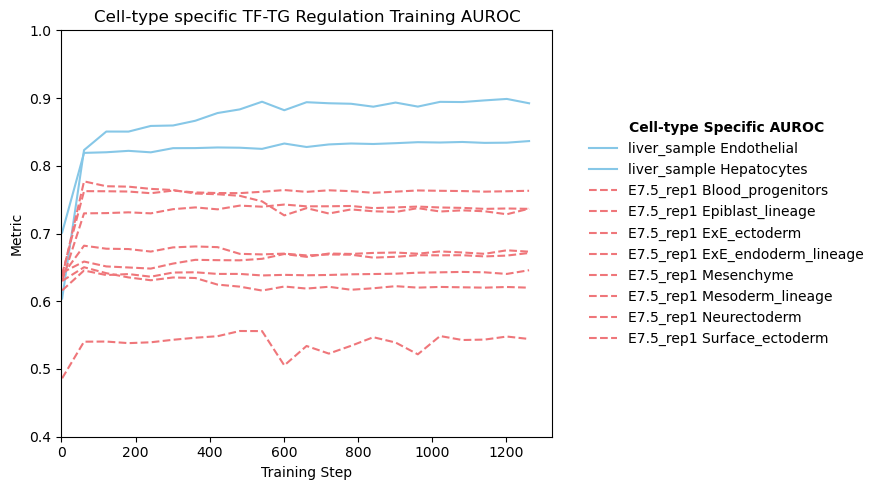

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(9, 5))

split = "val"
color_by_holdout = True
style_by_holdout = True

celltype_metric_name_map = {}
for tissue, sample in zip(sample_list["tissue"], sample_list["sample"]):
    split_celltypes = run.config[f"{tissue}__{sample}_{split}_celltypes"]
    
    split_metric_naming_convention = f"{split}/sample/{sample}/celltype/{{celltype}}/auroc"
    for celltype in split_celltypes:
        celltype_metric_name_map[(tissue, split, sample, celltype)] =  split_metric_naming_convention.format(celltype=celltype)

for (tissue, split, sample, celltype), metric_name in celltype_metric_name_map.items():
    metric_history = (
        run_history[["_step", metric_name]]
        .dropna()
        .sort_values("_step")
    )
    

    if f"{tissue}:{sample}" in holdout_samples or celltype in holdout_celltypes:
        color = "#EF767A" if color_by_holdout else None
        style = "--" if style_by_holdout else "-"
    else:
        color = "#86C7E7" if color_by_holdout else None
        style = "-" if style_by_holdout else "-"
    
    axes.plot(
        metric_history["_step"],
        metric_history[metric_name],
        label=f"{sample} {celltype}",
        color=color,
        linestyle=style,
    )

axes.set_title("Cell-type specific TF-TG Regulation Training AUROC")
axes.set_xlabel("Training Step")
axes.set_ylabel("Metric")
axes.set_ylim(0.4, 1)
axes.set_xlim(left=0)
axes.legend(
    bbox_to_anchor=(1.05, 0.5), 
    loc='center left',
    title="Cell-type Specific AUROC", 
    title_fontproperties={'weight': 'bold'}, 
    frameon=False
)

plt.tight_layout()

## Load Trained Model and Data

### Load Trained Model from Checkpoint

In [2]:
import models.tf_to_tg_celltype as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
from torch.utils.data import ConcatDataset, DataLoader
from scripts.train_tf_to_tg_celltype_model import (
    binding_score_cache_path,
    TFTGEdgeBagDataset,
)

def gpu_supports_torch_compile(device):
    if device.type != "cuda":
        return False

    major, minor = torch.cuda.get_device_capability(device)
    return major >= 7


def strip_compiled_prefix_from_state_dict(state_dict, prefix="_orig_mod."):
    """
    Remove torch.compile's _orig_mod prefix from state_dict keys.

    Examples:
        model._orig_mod.encoder.weight -> model.encoder.weight
        _orig_mod.encoder.weight       -> encoder.weight
    """
    cleaned = {}

    for key, value in state_dict.items():
        cleaned_key = key.replace(prefix, "")
        cleaned[cleaned_key] = value

    return cleaned


def load_tf_tg_regulation_model(
    tf_dna_model_path: Path,
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor,
    compile_model: bool = False,
    device: torch.device | None = None,
    model_module=None,
) -> tf_to_tg_module.LitTFTGRegulationModel:
    """
    model_module lets a caller load a checkpoint trained against a different
    TFTGRegulationModel definition than the default models.tf_to_tg -- e.g.
    models.tf_to_tg_testing while it is under active architecture changes there.
    Defaults to models.tf_to_tg (unchanged behaviour for every existing checkpoint).
    """
    model_module = model_module or tf_to_tg_module

    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if compile_model and not gpu_supports_torch_compile(device):
        if device.type == "cuda":
            major, minor = torch.cuda.get_device_capability(device)
            logging.warning(
                f"Skipping torch.compile because this GPU has compute capability "
                f"{major}.{minor}; Inductor/Triton requires >= 7.0."
            )
        else:
            logging.warning("Skipping torch.compile because device is not CUDA.")

        compile_model = False

    # -----------------------------
    # 1. Recreate base TF-DNA model uncompiled
    # -----------------------------
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # -----------------------------
    # 2. Load TF-DNA checkpoint
    # -----------------------------
    tf_dna_ckpt = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )

    tf_dna_state_dict = tf_dna_ckpt["state_dict"]

    if any("._orig_mod." in key or key.startswith("_orig_mod.") for key in tf_dna_state_dict):
        logging.info("Detected compiled TF-DNA checkpoint. Stripping _orig_mod prefixes.")
        tf_dna_state_dict = strip_compiled_prefix_from_state_dict(tf_dna_state_dict)

    lit_tf_dna_model = tf_to_dna_module.LitTFPeakBindingModel(
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    lit_tf_dna_model.load_state_dict(tf_dna_state_dict, strict=True)

    trained_tf_peak_model = lit_tf_dna_model.model
    trained_tf_peak_model.eval()

    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 3. Load TF-TG checkpoint
    # -----------------------------
    # load_from_checkpoint reconstructs the train-fitted expression and ATAC
    # scaler values from hyper_parameters. Loading only state_dict would silently
    # restore the default mean=0/std=1 because those scaler buffers are non-persistent.
    lit_tf_tg_model = model_module.LitTFTGRegulationModel.load_from_checkpoint(
        str(tf_tg_model_path), map_location="cpu",
    )
    lit_tf_tg_model.eval()

    for p in lit_tf_tg_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 5. Optional compile after loading
    # -----------------------------
    if compile_model:
        logging.info("Compiling loaded TF-TG core model.")
        lit_tf_tg_model.model = torch.compile(lit_tf_tg_model.model)

    # Evaluation needs the frozen TF-DNA model to recreate the binding scores.
    return lit_tf_tg_model, trained_tf_peak_model


def load_run_config(model_checkpoint: Path):
    run_dir = model_checkpoint.parent.parent
    with open(run_dir / "run_config.json") as handle:
        return json.load(handle)


def source_specs(run_config):
    configured = run_config.get("dataset")
    if not configured:
        configured = [f"{run_config['tissue']}:{run_config['sample_name']}"]
    if isinstance(configured, str):
        configured = [configured]
    return [tuple(value.split(":", 1)) for value in configured]


def load_multiome_data(run_config, tissue, sample_name):
    """
    Recreate the RNA and ATAC matrix order. 
    """
    
    data_dir = Path(run_config["data_dir"])
    mdata = mu.read(
        data_dir / "processed" / tissue
        / sample_name / "multiome_processed.h5mu"
    )
    rna = mdata.mod["rna"]
    atac = mdata.mod["atac"]
    shared_cells = rna.obs_names[rna.obs_names.isin(atac.obs_names)]
    rna = rna[shared_cells].copy()
    atac = atac[shared_cells].copy()

    max_autosome = 19 if run_config["species"] == "mm10" else 22
    valid_chroms = {f"chr{i}" for i in range(1, max_autosome + 1)}
    keep_peaks = np.array([
        peak.split(":", 1)[0] in valid_chroms for peak in atac.var_names
    ])
    atac = atac[:, keep_peaks].copy()
    rna.var_names = rna.var_names.str.upper()
    
    return rna, atac


def load_cell_pools(source_dir):
    with open(source_dir / "prepared_manifest.json") as handle:
        manifest = json.load(handle)
        
    cell_pools = {}
    with np.load(source_dir / "cell_pools.npz", allow_pickle=False) as archive:
        for pool in manifest["outputs"]["cell_pools"]:
            cell_pools[(pool["sample_id"], pool["cell_type"])] = (
                archive[pool["array_key"]].astype(np.int64, copy=False)
            )
    return cell_pools


def check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor):
    rna_names = eval_rna.var_names.to_numpy()
    assert np.array_equal(
        rna_names[split_df["tf_rna_col"].to_numpy()], split_df["tf_name"].to_numpy()
    )
    assert np.array_equal(
        rna_names[split_df["tg_rna_col"].to_numpy()], split_df["tg_id"].to_numpy()
    )
    assert atac_mat.shape[1] == atac_peak_tensor.shape[0]


def load_binding_scores(source_dir, split_name, split_df, run_config, tissue, sample_name):
    canonical_path = binding_score_cache_path(
        source_dir / "prepared", split_name, split_df,
        tf_dna_checkpoint=run_config["tf_dna_checkpoint"],
        max_peaks_per_tg=run_config["max_peaks_per_tg"],
    )
    
    config_key = f"{tissue}__{sample_name}_{split_name}_binding_cache"
    configured_path = Path(run_config.get(config_key, canonical_path))
    
    binding_path = canonical_path if canonical_path.exists() else configured_path
    if not binding_path.exists():
        raise FileNotFoundError(f"Binding scores not found at {binding_path}")
    
    binding_scores = torch.load(binding_path, map_location="cpu", weights_only=True)
    
    expected_shape = (len(split_df), run_config["max_peaks_per_tg"])
    if tuple(binding_scores.shape) != expected_shape:
        raise ValueError(
            f"{binding_path} has shape {tuple(binding_scores.shape)}; "
            f"expected {expected_shape}"
        )
    return binding_scores


def load_model_data(model_checkpoint: Path, split_name: str = "test"):
    """Load and concatenate every cached source used by a trained run."""
    logging.info(f"Loading model data for checkpoint {model_checkpoint} and split {split_name}")

    logging.info(f"  - Loading config")
    run_config = load_run_config(model_checkpoint)
    
    if split_name not in {"train", "val", "test"}:
        raise ValueError(f"Invalid split name: {split_name}")
    
    cache_dir = Path(run_config["cache_dir"])
    
    holdout_samples = set(run_config.get("holdout_sample", []))
    holdout_celltypes = set(run_config.get("holdout_celltype", []))
    
    dataset_parts = []
    source_edge_counts = {}
    for tissue, sample_name in source_specs(run_config):
        source_key = f"{tissue}__{sample_name}"
        
        if split_name == "train" and f"{tissue}:{sample_name}" in holdout_samples:
            logging.info(f"  - Skipping held-out training source {tissue}:{sample_name}")
            continue
        
        source_dir = cache_dir / "prepared_sources" / source_key
        
        if not source_dir.is_dir():
            raise FileNotFoundError(f"Prepared source cache not found: {source_dir}")

        logging.info(f"  - Loading {split_name} data for {tissue}:{sample_name}")
        
        split_df = pd.read_parquet(source_dir / f"edges_{split_name}.parquet")
        
        if split_name == "train" and holdout_celltypes:
            split_df = split_df.loc[
                ~split_df["cell_type"].isin(holdout_celltypes)
            ].reset_index(drop=True)
            
        if split_df.empty:
            continue

        atac_peak_tensor = torch.load(
            source_dir / "prepared" / sample_name / "atac_peak_tensor.pt",
            map_location="cpu", weights_only=True,
        )
        
        eval_rna, eval_atac = load_multiome_data(run_config, tissue, sample_name)
        
        rna_mat, atac_mat = eval_rna.X, eval_atac.X
        
        cell_pools = load_cell_pools(source_dir)
        
        check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor)
        
        split_binding_scores = load_binding_scores(
            source_dir, split_name, split_df, run_config, tissue, sample_name
        )
        
        dataset_parts.append(TFTGEdgeBagDataset(
            split_df,
            tf_embeddings_tensor=None, tf_mask_tensor=None,
            atac_peak_tensor=atac_peak_tensor, atac_mat=atac_mat, rna_mat=rna_mat,
            cell_pools=cell_pools,
            max_peaks_per_tg=run_config["max_peaks_per_tg"],
            resample_max_cells_per_pair=run_config["max_cells_per_pair"],
            resample_cells=False, binding_scores=split_binding_scores,
            seed=run_config["seed"],
        ))
        source_edge_counts[f"{tissue}:{sample_name}"] = len(split_df)

    if not dataset_parts:
        raise ValueError(f"No {split_name} datasets were available")
    split_dataset = (
        dataset_parts[0] if len(dataset_parts) == 1 else ConcatDataset(dataset_parts)
    )

    logging.info(f"  - Creating dataloader")
    split_dataloader = DataLoader(
        split_dataset, batch_size=run_config["batch_size"], shuffle=False,
        num_workers=run_config["num_workers"],
        persistent_workers=run_config["num_workers"] > 0,
        pin_memory=device.type == "cuda", drop_last=False,
        prefetch_factor=4 if run_config["num_workers"] > 0 else None
    )
    
    print(
        f"Loaded {len(split_dataset):,} {split_name} edges from "
        f"{source_edge_counts} in {len(split_dataloader):,} batches. "
        "Inputs remain unscaled; the checkpoint model applies its saved scaler."
    )
    
    return split_dataset, split_dataloader, run_config


def run_batch(trained_model, batch_cpu, train: bool, microbatch_size: int = 64):
    """One batch, microbatched. Returns (loss, edge_logits, labels), all on CPU."""
    B = len(batch_cpu["label"])
    
    gpu_keys = [
        "binding_score", "peak_accessibility", "peak_distance",
        "tf_expression", "tg_expression", "cell_mask", "peak_mask", "label",
    ]

    edge_parts, total_loss = [], 0.0
    for start in range(0, B, microbatch_size):
        end = min(start + microbatch_size, B)
        microbatch = {k: batch_cpu[k][start:end].to(device) for k in gpu_keys}

        with torch.set_grad_enabled(train):
            edge_logits, _ = trained_model(microbatch)
            loss = nn.functional.binary_cross_entropy_with_logits(
                edge_logits, microbatch["label"].float(), reduction="sum",
            ) / B

        if train:
            loss.backward()

        total_loss += loss.item()
        edge_parts.append(edge_logits.detach().cpu())
        del microbatch, edge_logits, loss

    return total_loss, torch.cat(edge_parts), batch_cpu["label"].float()


@torch.no_grad()
def evaluate(model, loader, desc="Evaluating"):
    model.eval()

    logits, labels = [], []
    loss_sum = 0.0
    n = 0

    progress = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        unit="batch",
        dynamic_ncols=True,
    )

    for batch_cpu in progress:
        b = len(batch_cpu["label"])

        # run_batch already manages gradient mode.
        loss, edge_logits, y = run_batch(
            model,
            batch_cpu,
            train=False,
        )

        # run_batch returns mean loss over this batch.
        loss_sum += loss * b
        n += b

        logits.append(edge_logits)
        labels.append(y)

        progress.set_postfix(
            loss=f"{loss_sum / n:.4f}",
            edges=n,
        )

    logits = torch.cat(logits)
    labels = torch.cat(labels)
    probabilities = logits.sigmoid()
    avg_loss = loss_sum / n

    if labels.min() != labels.max():
        auroc = roc_auc_score(
            labels.numpy(),
            probabilities.numpy(),
        )
    else:
        auroc = float("nan")

    return avg_loss, auroc, probabilities, labels



In [3]:
species = "mm10"

model_run_name = "celltype_joint_3884265_20260921_100434_418733"

mm10_tf_dna_path = CHKPT_DIR / "new_tf_dna_models" / "mm10_3831017_epoch_12.ckpt"
model_checkpoint = CHKPT_DIR / "celltype_tf_tg" / model_run_name / "checkpoints" / "last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tf_dna_input_cache_dir = PROJECT_DIR / "cached_data" / species / "tf_dna_cache"
tf_embedding_cache_path = tf_dna_input_cache_dir / "tf_embeddings.pt"
tf_mask_cache_path = tf_dna_input_cache_dir / "tf_masks.pt"

tf_embeddings_tensor = torch.load(tf_embedding_cache_path, weights_only=True)
tf_mask_tensor = torch.load(tf_mask_cache_path, weights_only=True)

trained_model, trained_tf_peak_model = load_tf_tg_regulation_model(
    tf_dna_model_path=mm10_tf_dna_path,
    tf_tg_model_path=model_checkpoint,
    tf_embeddings_tensor= tf_embeddings_tensor,
    tf_mask_tensor= tf_mask_tensor,
    compile_model=False,
    device=device,
    model_module=tf_to_tg_module,
)

trained_model

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


LitTFTGRegulationModel(
  (model): SimpleTFTGRegulationModel(
    (peak_feature_proj): Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): SiLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
    )
    (tf_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_query_proj): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (peak_attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (norm): Layer

### Load Trained Model Data

In [4]:
test_dataset, test_dataloader, test_run_config = load_model_data(
    model_checkpoint=model_checkpoint, split_name="test"
)

2026-09-24 15:30:14,621 - INFO - Loading model data for checkpoint /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3884265_20260921_100434_418733/checkpoints/last.ckpt and split test
2026-09-24 15:30:14,622 - INFO -   - Loading config
2026-09-24 15:30:14,628 - INFO -   - Loading test data for mouse_liver:liver_sample
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var

Loaded 248,010 test edges from {'mouse_liver:liver_sample': 86667, 'mESC:E7.5_rep1': 161343} in 485 batches. Inputs remain unscaled; the checkpoint model applies its saved scaler.


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 24 worker processes in total. Our suggested max number of worker in current system is 10, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


### Generate test set predictions

In [5]:
trained_model = trained_model.to(device)
test_set_grn_path = model_checkpoint.parent.parent / "test_set_grn.csv"

training_sample_list = [sample.split(":")[1] for sample in test_run_config["dataset"] if sample not in test_run_config["holdout_sample"]]
trainin_sample_names = "_".join(training_sample_list)

if not test_set_grn_path.is_file():
    print(f"Generating GRN for {trainin_sample_names} model test")
    eval_loss, eval_auroc, eval_probs, eval_labels = evaluate(trained_model, test_dataloader)

    # Combine the inputs from all test datasets and add the probabilities
    inputs = pd.concat([ds.inputs for ds in test_dataset.datasets], ignore_index=True)
    test_set_predictions = inputs[[
        "sample_id", "cell_type", "tf_name", "tg_id", "label"
    ]].copy()
    test_set_predictions["probability"] = eval_probs.numpy()
    test_set_predictions["predicted_label"] = (
        test_set_predictions["probability"] >= 0.5
    ).astype(np.int8)

    grn_columns = ["SampleID", "CellType", "Source", "Target", "Score", "Label"]
    test_set_grn = (
        test_set_predictions
        .rename(columns={
            "sample_id": "SampleID",
            "cell_type": "CellType",
            "tf_name": "Source",
            "tg_id": "Target",
            "probability": "Score",
            "label": "Label"
        })
        .loc[:, grn_columns]
        .assign(
            Source=lambda frame: frame["Source"].astype(str).str.upper(),
            Target=lambda frame: frame["Target"].astype(str).str.upper(),
        )
    )

    self_trained_grn = test_set_grn[test_set_grn["SampleID"].isin(training_sample_list)]
    
    self_trained_grn.to_csv(test_set_grn_path, index=False)
else:
    self_trained_grn = pd.read_csv(test_set_grn_path)

display(self_trained_grn)

,SampleID,CellType,Source,Target,Score,Label
0,liver_sample,Hepatocytes,FOXA2,GM36602,0.550243,False
1,liver_sample,Fibroblasts,FOXA3,VWCE,0.255456,True
2,liver_sample,Hepatocytes,SETDB1,GM45871,0.257542,True
3,liver_sample,T cells,STAT1,RAB18,0.836706,True
4,liver_sample,Hepatocytes,CREB1,LZTS2,0.660495,True
...,...,...,...,...,...,...
86662,liver_sample,T cells,ETS1,GM50399,0.523772,False
86663,liver_sample,T cells,CTCF,VPS13A,0.680141,True
86664,liver_sample,Hepatocytes,CEBPA,PPP1R14B,0.616108,True
86665,liver_sample,Fibroblasts,GATA4,CLCF1,0.312362,False


## Cross-Trained Model Predictions


Set `evaluation_tissue` and `evaluation_sample` to evaluate any existing processed dataset. The selected cell types held out from training are evaluated on their complete edge sets, combining train-, validation-, and test-chromosome rows. The checkpoint applies its saved training scaler during inference; no scaler is refit here.

In [8]:
torch.cuda.set_per_process_memory_fraction(1.0, device=0) 
torch.cuda.empty_cache(); gc.collect()

# Change only these two values to select an existing processed dataset.
evaluation_tissue, evaluation_sample = "mESC", "E7.5_rep1"

# Set this to True to use all cell types, or False to use only the holdout cell types.
use_all_celltypes = True

# Set this to limit the number of edges to run predictions for
# (set to None to run all)
max_evaluation_edges = None

evaluation_grn_path = model_checkpoint.parent.parent / f"{evaluation_sample}_cross_grn.csv"

force_regenerate_cross_eval_grn = False

if not evaluation_grn_path.is_file() or force_regenerate_cross_eval_grn:
    source_key = f"{evaluation_tissue}__{evaluation_sample}"
    run_cache_dir = Path(test_run_config["cache_dir"])
    source_cache_dir = run_cache_dir / "prepared_sources" / source_key
    evaluation_data_path = (
        Path(test_run_config["data_dir"]) / "processed"
        / evaluation_tissue / evaluation_sample / "multiome_processed.h5mu"
    )
    if not evaluation_data_path.is_file():
        processed_dir = Path(test_run_config["data_dir"]) / "processed"
        available_datasets = sorted(
            str(path.parent.relative_to(processed_dir)).replace(os.sep, ":")
            for path in processed_dir.glob("*/*/multiome_processed.h5mu")
        )
        raise FileNotFoundError(
            f"Evaluation dataset does not exist: {evaluation_data_path}. "
            f"Available tissue:sample datasets: {available_datasets}"
        )

    evaluation_dir = (
        model_checkpoint.parent.parent / "holdout_evaluation" / source_key
    )
    evaluation_dir.mkdir(parents=True, exist_ok=True)

    cache_manifest_path = run_cache_dir / "cache_manifest.json"
    with open(cache_manifest_path) as handle:
        prepared_cache_manifest = json.load(handle)

    # Prepare the evaluation data using the saved model config
    evaluation_args = SimpleNamespace(
        species=test_run_config["species"],
        tissue=evaluation_tissue,
        sample_name=evaluation_sample,
        data_dir=Path(test_run_config["data_dir"]),
        gene_ref_file=None,
        output_dir=source_cache_dir,
        num_workers=test_run_config["num_workers"],
        max_cells_per_pair=test_run_config["max_cells_per_pair"],
        max_peaks_per_tg=test_run_config["max_peaks_per_tg"],
        peak_flank_size=test_run_config["peak_flank_size"],
        true_false_ratio=test_run_config["true_false_ratio"],
        balance_tf=test_run_config["balance_tf"],
        balance_tg=test_run_config["balance_tg"],
        min_cells_per_slice=test_run_config["min_cells_per_slice"],
        min_tfs_per_slice=test_run_config["min_tfs_per_slice"],
        max_gt_density=test_run_config["max_gt_density"],
        seed=test_run_config["seed"],
        prepared_cache_manifest=prepared_cache_manifest
    )

    # Prepare the data for the new sample
    (
        evaluation_splits, evaluation_cell_pools, evaluation_atac_mat, evaluation_rna_mat,
        evaluation_peak_tensor, evaluation_embedding_path, evaluation_mask_path,
    ) = prepare_data(evaluation_args)

    holdout_celltypes = set(test_run_config.get("holdout_celltype", []))
    
    holdout_frames = []
    for chromosome_split in ("train", "val", "test"):
        split_frame = evaluation_splits.get(chromosome_split)
        
        if use_all_celltypes == True:
            split_frame["chromosome_split"] = chromosome_split
            holdout_frames.append(split_frame)
            
        else:
            
            if not holdout_celltypes:
                raise ValueError("The selected run did not hold out any cell types")
            
            if split_frame is None or split_frame.empty:
                continue
            
            split_holdouts = split_frame[
                split_frame["cell_type"].isin(holdout_celltypes)
            ].copy()
            
            if not split_holdouts.empty:
                split_holdouts["chromosome_split"] = chromosome_split
                holdout_frames.append(split_holdouts)

    if not holdout_frames:
        raise ValueError(
            f"None of {sorted(holdout_celltypes)} occur in "
            f"{evaluation_tissue}:{evaluation_sample}"
        )
    evaluation_holdout_frame = pd.concat(holdout_frames, ignore_index=True)

    if max_evaluation_edges is None:
        max_evaluation_edges = len(evaluation_holdout_frame)
        
    evaluation_subset_frame = (
        evaluation_holdout_frame
        .sample(
            n=min(max_evaluation_edges, len(evaluation_holdout_frame)),
            random_state=evaluation_args.seed,
            replace=False,
        )
        .reset_index(drop=True)
    )

    print(
        f"Selected {len(evaluation_subset_frame):,} of "
        f"{len(evaluation_holdout_frame):,} evaluation edges"
    )

    evaluated_holdouts = sorted(evaluation_holdout_frame["cell_type"].unique())
    missing_source_holdouts = sorted(set(holdout_celltypes).difference(set(evaluated_holdouts)))

    # Load or precompute the binding scores for the evaluation subset
    trained_tf_peak_model = trained_tf_peak_model.to(device)
    binding_tf_embeddings = tf_embeddings_tensor.to(device=device, dtype=torch.float32)
    binding_tf_masks = tf_mask_tensor.to(device=device, dtype=torch.bool)
    evaluation_binding_peak_tensor = evaluation_peak_tensor.to(device=device, dtype=torch.uint8)

    try:
        binding_result = load_or_precompute_binding_scores(
            "evaluation_subset",
            evaluation_subset_frame,
            trained_tf_peak_model,
            prepared_dir=evaluation_dir / "prepared",
            tf_dna_checkpoint=Path(test_run_config["tf_dna_checkpoint"]),
            tf_embeddings_tensor=binding_tf_embeddings,
            tf_mask_tensor=binding_tf_masks,
            atac_peak_tensor=evaluation_binding_peak_tensor,
            max_peaks_per_tg=evaluation_args.max_peaks_per_tg,
            device=device,
            chunk_size=test_run_config.get("binding_chunk_size", 2048),
            full_tqdm=True,
        )

        if len(binding_result) == 2:
            evaluation_binding_scores, evaluation_binding_cache = binding_result
            gpu_usage = {}
        else:
            (
                evaluation_binding_scores,
                evaluation_binding_cache,
                gpu_usage,
            ) = binding_result
    finally:
        del evaluation_binding_peak_tensor, binding_tf_embeddings, binding_tf_masks
        trained_tf_peak_model = trained_tf_peak_model.cpu()
        if device.type == "cuda":
            torch.cuda.empty_cache()

    # Create the evaluation subset dataset and dataloader
    evaluation_subset_dataset = TFTGEdgeBagDataset(
        evaluation_subset_frame,
        tf_embeddings_tensor=None,
        tf_mask_tensor=None,
        atac_peak_tensor=evaluation_peak_tensor,
        atac_mat=evaluation_atac_mat,
        rna_mat=evaluation_rna_mat,
        cell_pools=evaluation_cell_pools,
        max_peaks_per_tg=evaluation_args.max_peaks_per_tg,
        resample_max_cells_per_pair=evaluation_args.max_cells_per_pair,
        resample_cells=False,
        binding_scores=evaluation_binding_scores,
        seed=evaluation_args.seed,
    )
    evaluation_subset_dataloader = DataLoader(
        evaluation_subset_dataset,
        batch_size=test_run_config["batch_size"],
        shuffle=False,
        num_workers=test_run_config["num_workers"],
        persistent_workers=test_run_config["num_workers"] > 0,
        pin_memory=device.type == "cuda",
        drop_last=False,
        prefetch_factor=4 if test_run_config["num_workers"] > 0 else None
    )

    # Create an evaluation build configuration file
    evaluation_build_config = {
        key: str(value) if isinstance(value, Path) else value
        for key, value in vars(evaluation_args).items()
    }
    evaluation_build_config.update({
        "source_cache_dir": str(source_cache_dir),
        "binding_cache": str(evaluation_binding_cache),
        "requested_holdout_celltypes": sorted(holdout_celltypes),
        "evaluated_holdout_celltypes": evaluated_holdouts,
        "missing_source_holdout_celltypes": missing_source_holdouts,
        "chromosome_splits": ["train", "val", "test"],
        "n_edges": len(evaluation_subset_frame),
    })
    (evaluation_dir / "evaluation_config.json").write_text(
        json.dumps(evaluation_build_config, indent=2)
    )
    print(
        f"Built {len(evaluation_subset_dataset):,} subset holdout edges for "
        f"{evaluation_tissue} {evaluation_sample}: {evaluated_holdouts}; "
        f"{len(evaluation_subset_dataloader):,} batches"
    )
    
    trained_model = trained_model.to(device)
    
    # Run predictions for the evaluation sample
    subset_loss, subset_auroc, subset_probs, subset_labels = evaluate(
        trained_model,
        evaluation_subset_dataloader,
    )

    print(
        f"{evaluation_tissue} {evaluation_sample} subset "
        f"({len(evaluation_subset_frame):,} edges): "
        f"loss={subset_loss:.4f}; AUROC={subset_auroc:.4f}"
    )

    inputs = evaluation_subset_dataset.inputs
    evaluation_subset_predictions = inputs[[
        "sample_id", "cell_type", "tf_name", "tg_id", "label"
    ]].copy()

    evaluation_subset_predictions["probability"] = subset_probs.numpy()
    evaluation_subset_predictions["predicted_label"] = (
        evaluation_subset_predictions["probability"] >= 0.5
    ).astype(np.int8)

    grn_columns = ["SampleID", "CellType", "Source", "Target", "Score", "Label"]
    evaluation_grn = (
        evaluation_subset_predictions
        .rename(columns={
            "sample_id": "SampleID",
            "cell_type": "CellType",
            "tf_name": "Source",
            "tg_id": "Target",
            "probability": "Score",
            "label": "Label"
        })
        .loc[:, grn_columns]
        .assign(
            Source=lambda frame: frame["Source"].astype(str).str.upper(),
            Target=lambda frame: frame["Target"].astype(str).str.upper(),
        )
    )
    evaluation_grn.to_csv(evaluation_grn_path, index=False)
else:
    print(f"Loading evaluation GRN from {evaluation_grn_path}")
    evaluation_grn = pd.read_csv(evaluation_grn_path)


display(evaluation_grn.head())


2026-09-24 15:33:48,765 - INFO -  Building for Sample: E7.5_rep1, Tissue: mESC




mm10 mESC E7.5_rep1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
2026-09-24 15:33:50,474 - INFO - Loaded MuData object:
2026-09-24 15:33:50,474 - INFO -   6,83

RNA: (6832, 18637)
ATAC: (6832, 192589)
Sequence peaks: 192589
Annotated cell types: 36


2026-09-24 15:33:58,156 - INFO - mESC:E7.5_rep1 loaded prepared inputs from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/cached_data/mm10/celltype_tf_tg/96e092364c557987/prepared_sources/mESC__E7.5_rep1


...

2026-09-24 15:58:25,707 - INFO - evaluation_subset: cached binding scores (2455775, 25) at /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3884265_20260921_100434_418733/holdout_evaluation/mESC__E7.5_rep1/prepared/binding_scores_evaluation_subset_e5fe3ac3f98ce6f3.pt


Built 2,455,775 subset holdout edges for mESC E7.5_rep1: ['Blood_progenitors', 'Epiblast_lineage', 'ExE_ectoderm', 'ExE_endoderm_lineage', 'Mesenchyme', 'Mesoderm_lineage', 'Neurectoderm', 'Surface_ectoderm']; 4,797 batches


Evaluating: 100%|█████████████████████████████████████████████| 4797/4797 [32:48<00:00,  2.44batch/s, edges=2455775, loss=0.6005]


mESC E7.5_rep1 subset (2,455,775 edges): loss=0.6005; AUROC=0.6874


,SampleID,CellType,Source,Target,Score,Label
0,E7.5_rep1,Blood_progenitors,TCF3,GNB1L,0.394892,False
1,E7.5_rep1,Surface_ectoderm,AHR,OSBPL8,0.152596,False
2,E7.5_rep1,Mesoderm_lineage,POU2F1,LNPK,0.236295,True
3,E7.5_rep1,Neurectoderm,BCL6,RRAGA,0.139683,False
4,E7.5_rep1,Epiblast_lineage,TBR1,SAP18B,0.207187,False


## Cross-trained model vs other inference methods

In [9]:
other_method_grn_dir = Path(
    "/gpfs/Labs/Uzun/DATA/PROJECTS/"
    "2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/"
    "other_method_celltype_grns"
)

method_dirs = sorted(
    path for path in other_method_grn_dir.iterdir()
    if path.is_dir()
)

method_names = [method_dir.name for method_dir in method_dirs]

In [10]:
def load_celltype_ground_truth(gt_file_index, celltype):
    celltype_file_name = celltype.replace(" ", "_")

    gt_filename = f"{celltype_file_name}_ground_truth.parquet"
    gt_path = gt_file_index.get(gt_filename)

    if gt_path is None:
        print(f"No ground truth found for {celltype}")
        return None

    # Load and prepare this cell type's GT once.
    # Note: GT is already filtered to TFs with embeddings
    gt = pd.read_parquet(
        gt_path,
        columns=["Source", "Target"],
    )

    gt = (
        gt.assign(
            Source=gt["Source"].astype(str).str.upper(),
            Target=gt["Target"].astype(str).str.upper(),
        )
        .drop_duplicates(["Source", "Target"])
    )
    
    return gt

def normalize_pairs(df):
    """
    Normalize the Source and Target columns in the DataFrame.
    """
    df = df.dropna(subset=["Source", "Target"]).copy()
    for col in ["Source", "Target"]:
        df[col] = df[col].astype(str).str.strip().str.upper()
    return df

def generate_edge_universe_from_gt(gt):
    """
    Generate a universe of all possible edges from the ground truth.
    """
    
    gt = normalize_pairs(gt).drop_duplicates(["Source", "Target"])

    universe = pd.MultiIndex.from_product(
        [
            sorted(gt["Source"].unique()),
            sorted(gt["Target"].unique()),
        ],
        names=["Source", "Target"],
    ).to_frame(index=False)

    positive_pairs = pd.MultiIndex.from_frame(gt[["Source", "Target"]])
    candidate_pairs = pd.MultiIndex.from_frame(universe[["Source", "Target"]])
    universe["_in_gt"] = candidate_pairs.isin(positive_pairs).astype("int8")
    return universe

def sample_auprc_10x_negatives(full_universe, random_state=42):
    """Keep all positives, sample negatives at 10x the positive count."""
    positives = full_universe[full_universe["_in_gt"] == 1]
    negatives = full_universe[full_universe["_in_gt"] == 0]

    n_pos = len(positives)
    n_neg_sample = min(n_pos * 10, len(negatives))

    if n_pos == 0 or n_neg_sample == 0:
        return full_universe.iloc[0:0].copy()

    neg_sampled = negatives.sample(
        n=n_neg_sample,
        replace=False,
        random_state=random_state,
    )

    auprc_df = pd.concat([positives, neg_sampled], axis=0)
    auprc_df = auprc_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    return auprc_df

def filter_df_to_gene_set(df, gene_set1, gene_set2):
    df = df.copy()
    df = df[
        df["Source"].isin(gene_set1) & df["Target"].isin(gene_set2)
    ]
    return df

def label_grn_with_universe(grn, universe, missing_score=np.nan):
    predictions = normalize_pairs(grn[["Source", "Target", "Score"]])
    # Absolute scores: signed methods (e.g. regression coefficients) rank by strength.
    predictions["Score"] = pd.to_numeric(predictions["Score"], errors="coerce").abs()
    predictions = predictions.loc[np.isfinite(predictions["Score"])].copy()

    # Keep the maximum score for duplicate TF-TG pairs.
    predictions = predictions.groupby(["Source", "Target"], as_index=False)["Score"].max()

    labeled = universe[["Source", "Target", "_in_gt"]].merge(
        predictions,
        on=["Source", "Target"],
        how="left",
        validate="one_to_one",
    )
    labeled["Score"] = labeled["Score"].fillna(missing_score)
    labeled = labeled.dropna(subset=["Score"])
    
    return labeled

def generate_hash_key(sample_celltype_df, other_method_names):
    # Create a hash of the sample, cell type, and method lists
    rows = [
        {
            "sample": str(sample),
            "eval_type": str(eval_type),
            "celltypes": sorted(set(map(str, celltypes))),
        }
        for sample, eval_type, celltypes
        in sample_celltype_df.itertuples(index=False, name=None)
    ]

    payload = {
        "rows": sorted(rows, key=lambda row: json.dumps(row, sort_keys=True)),
        "other_methods": sorted(set(map(str, other_method_names))),
    }

    canonical = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    hash_key = hashlib.sha256(canonical.encode("utf-8")).hexdigest()[:8]
    
    return hash_key

SELF_MODEL_METHOD = "TF-TG Model (self-trained)"
CROSS_MODEL_METHOD = "TF-TG Model (cross-trained)"

self_trained_grn["EvalType"] = SELF_MODEL_METHOD
evaluation_grn["EvalType"] = CROSS_MODEL_METHOD

sample_celltype_df = pd.concat([
    evaluation_grn[["EvalType", "SampleID", "CellType"]].drop_duplicates(),
    self_trained_grn[["EvalType", "SampleID", "CellType"]].drop_duplicates()
])

sample_celltype_df = sample_celltype_df.groupby(["SampleID", "EvalType"])["CellType"].apply(list).reset_index()

# Create a map from sample names to tissue names, ensuring that the processed data files exist.
sample_to_tissue_map = {}
for data_dir in (Path(test_run_config["data_dir"]) / "processed").iterdir():
    tissue = data_dir.name
    for file_path in data_dir.rglob("*/multiome_processed.h5mu"):
        sample_name = file_path.parent.name
        data_file = file_path
        sample_to_tissue_map[sample_name] = tissue

cell_type_specific_gt_dir = (
    DATA_DIR / "ground_truth_files" / "cell_type_specific"
)

other_method_grn_dir = Path(
    "/gpfs/Labs/Uzun/DATA/PROJECTS/"
    "2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/"
    "other_method_celltype_grns"
)

other_method_dirs = sorted(
    path for path in other_method_grn_dir.iterdir()
    if path.is_dir()
)

other_method_names = [method_dir.name for method_dir in other_method_dirs]

species_gt_dir = cell_type_specific_gt_dir / species
gt_file_index = {path.name: path for path in species_gt_dir.rglob("*_ground_truth.parquet")}

cache_dir = Path(test_run_config["cache_dir"])
hash_key = generate_hash_key(sample_celltype_df, other_method_names)
method_dict_file = cache_dir / f"method_grn_cache_v2_{hash_key}.pkl"

# Try to load the method_grn_dict from the cache
requires_regen = True
if method_dict_file.is_file():
    try:
        with open(method_dict_file, "rb") as f:
            cached = pickle.load(f)
        method_grn_dict = cached["method_grn_dict"]
        celltype_gt_dict = cached["celltype_gt_dict"]
        requires_regen = False
    except Exception as e:
        logging.warning(f"Error loading cache: {e}")
        os.remove(method_dict_file)
        
if requires_regen:
    logging.warning("Cache is incomplete. Re-generating...")
    method_grn_dict = {}
    celltype_gt_dict = {}  # {sample: {celltype: GT edges}}; the metric universe is GT TFs x GT targets
    # Generate the labeled filtered GRNs for each method/sample/celltype
    for sample_name, eval_type, sample_celltypes in sample_celltype_df.itertuples(index=False):
        
        logging.info(f"Sample: {sample_name}, Eval Type: {eval_type}")
        sample_results = method_grn_dict.setdefault(sample_name, {})
        
        # Load the multiomic dataset for the current sample
        tissue = sample_to_tissue_map.get(sample_name, "Unknown")
        assert tissue != "Unknown", f"Could not find tissue for sample: {sample_name}"
        data_path = Path(test_run_config["data_dir"]) / "processed" / tissue / sample_name / "multiome_processed.h5mu"
        sample_genes = set(mu.read(f"{data_path}/rna").var_names.str.upper())
        logging.info(f"  Genes in sample: {len(sample_genes)}")
        
        for celltype in sample_celltypes:
            logging.info(f"  Cell Type: {celltype}")
            celltype_results = sample_results.setdefault(celltype, {})
            
            # Load the ground truth for the current cell type
            celltype_gt = load_celltype_ground_truth(gt_file_index, celltype)
            
            if celltype_gt is None:
                logging.warning(f"      - No ground truth found for {celltype}")
                continue
            
            # Filter the ground truth to only include genes that are present in the current sample
            celltype_gt = filter_df_to_gene_set(celltype_gt, sample_genes, sample_genes)
            logging.info(f"      - Ground truth for {celltype}: {len(celltype_gt)} edges")
            
            if celltype_gt.empty:
                logging.warning(f"      - Ground truth for {celltype} has no edges in {sample_name}; skipping")
                continue

            celltype_gt = normalize_pairs(celltype_gt).drop_duplicates(["Source", "Target"])
            celltype_gt_dict.setdefault(sample_name, {})[celltype] = celltype_gt

            # Create the edge universe from the ground truth
            full_universe = generate_edge_universe_from_gt(celltype_gt)
            logging.info(f"      - Edge universe for {celltype}: {len(full_universe)} edges")
            
            # Generate a 1:10 True:False ratio for calculating AURPC
            auprc_eval_universe = sample_auprc_10x_negatives(full_universe)
            if auprc_eval_universe["_in_gt"].nunique() < 2:
                logging.warning(f"      - AUPRC universe for {celltype} lacks positives or negatives")
            
            gt_tfs = full_universe["Source"].unique()
            gt_targets = full_universe["Target"].unique()
            
            auroc_gt_tfs = auprc_eval_universe["Source"].unique()
            auroc_gt_targets = auprc_eval_universe["Target"].unique()

            # Get the model predictions for the current sample and cell type
            if eval_type == SELF_MODEL_METHOD:
                monica_grn = self_trained_grn.copy()
                
            if eval_type == CROSS_MODEL_METHOD:
                monica_grn = evaluation_grn.copy()

            monica_grn = monica_grn[
                (monica_grn["SampleID"] == sample_name) & (monica_grn["CellType"] == celltype)
            ].copy()
            
            # Filter the GRN to only contain edges that are in the sample
            monica_grn = filter_df_to_gene_set(monica_grn, sample_genes, sample_genes)

            # Label the GRN against each universe
            monica_grn_universe_labeled = label_grn_with_universe(monica_grn, full_universe)
            monica_grn_auprc_labeled = label_grn_with_universe(monica_grn, auprc_eval_universe)

            celltype_results[eval_type] = {}
            celltype_results[eval_type]["full_universe"] = monica_grn_universe_labeled
            celltype_results[eval_type]["auprc_universe"] = monica_grn_auprc_labeled

            for other_method_name in other_method_names:
                grn_filename = f"{other_method_name.lower().replace('_', '')}_{celltype.replace(' ', '_')}_{sample_name}.tsv"
                other_method_grn_path = other_method_grn_dir / other_method_name / grn_filename
                celltype_results[other_method_name] = {}
                
                if not other_method_grn_path.exists():
                    logging.warning(f"      - No {other_method_name} GRN found for {celltype} in {sample_name}")
                    continue
                
                # Load the GRN for the current method and cell type.
                other_method_grn = pd.read_csv(
                    other_method_grn_path,
                    sep="\t",
                    usecols=["Source", "Target", "Score"],
                )
                
                assert all(col in other_method_grn.columns for col in ["Source", "Target", "Score"]),\
                    f"Expected columns not found in the data: {[col for col in ['Source', 'Target', 'Score'] if col not in other_method_grn.columns]}"

                # Label the GRN against each universe (normalizes names and keeps the max score per pair).
                other_method_grn_universe_labeled = label_grn_with_universe(other_method_grn, full_universe)
                other_method_grn_auprc_labeled = label_grn_with_universe(other_method_grn, auprc_eval_universe)
                
                # Scale Scores to [0, 1] range
                other_method_grn_universe_labeled["Score"] = (
                    other_method_grn_universe_labeled["Score"] - other_method_grn_universe_labeled["Score"].min()
                ) / (
                    other_method_grn_universe_labeled["Score"].max() - other_method_grn_universe_labeled["Score"].min()
                )

                # Add the other method's GRN to the dictionary.
                celltype_results[other_method_name]["full_universe"] = other_method_grn_universe_labeled
                celltype_results[other_method_name]["auprc_universe"] = other_method_grn_auprc_labeled

    with open(method_dict_file, "wb") as f:
        pickle.dump({"method_grn_dict": method_grn_dict, "celltype_gt_dict": celltype_gt_dict}, f)

2026-09-24 16:31:21,854 - WARNING - Cache is incomplete. Re-generating...
2026-09-24 16:31:21,855 - INFO - Sample: E7.5_rep1, Eval Type: TF-TG Model (cross-trained)
2026-09-24 16:31:22,103 - INFO -   Genes in sample: 18637
2026-09-24 16:31:22,103 - INFO -   Cell Type: Blood_progenitors
2026-09-24 16:31:22,678 - INFO -       - Ground truth for Blood_progenitors: 151390 edges
2026-09-24 16:31:23,048 - INFO -       - Edge universe for Blood_progenitors: 520736 edges
2026-09-24 16:31:50,709 - INFO -   Cell Type: Surface_ectoderm
2026-09-24 16:31:51,070 - INFO -       - Ground truth for Surface_ectoderm: 39551 edges
2026-09-24 16:31:51,179 - INFO -       - Edge universe for Surface_ectoderm: 134160 edges
2026-09-24 16:32:22,109 - INFO -   Cell Type: Mesoderm_lineage
2026-09-24 16:32:22,440 - INFO -       - Ground truth for Mesoderm_lineage: 25650 edges
2026-09-24 16:32:22,523 - INFO -       - Edge universe for Mesoderm_lineage: 98288 edges
2026-09-24 16:33:05,820 - INFO -   Cell Type: Neure

In [11]:
from scipy.stats import hypergeom
from sklearn.metrics import roc_auc_score


def _safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan
    return float(numerator / denominator)


def _benjamini_hochberg(p_values):
    """Return Benjamini-Hochberg adjusted p-values without statsmodels."""
    p_values = np.asarray(p_values, dtype=float)
    if p_values.size == 0:
        return np.array([], dtype=float)

    order = np.argsort(p_values, kind="stable")
    ranked_p = p_values[order]
    ranks = np.arange(1, len(ranked_p) + 1, dtype=float)

    ranked_q = ranked_p * len(ranked_p) / ranks
    ranked_q = np.minimum.accumulate(ranked_q[::-1])[::-1]
    ranked_q = np.clip(ranked_q, 0.0, 1.0)

    q_values = np.empty_like(ranked_q)
    q_values[order] = ranked_q
    return q_values


def _pr_auc_integral(labels, scores):
    """
    AUPRC with continuous interpolation between PR points.

    Matches PRROC ``pr.curve(...)$auc.integral`` (checked against PRROC 1.4,
    including heavily tied scores). Between two PR points, FP grows linearly
    with TP, so precision(x) = x / (a*x + b) and each segment integrates exactly.
    """
    labels = np.asarray(labels, dtype=bool)
    scores = np.asarray(scores, dtype=float)
    n_pos = labels.sum()
    if n_pos == 0 or n_pos == len(labels):
        return np.nan

    order = np.argsort(-scores, kind="stable")
    sorted_scores = scores[order]
    sorted_labels = labels[order]

    # Cumulative TP/FP at the end of each group of tied scores.
    last_of_tie = np.r_[sorted_scores[1:] != sorted_scores[:-1], True]
    tp = np.r_[0, np.cumsum(sorted_labels)[last_of_tie]].astype(float)
    fp = np.r_[0, np.cumsum(~sorted_labels)[last_of_tie]].astype(float)

    tp0, tp1, fp0, fp1 = tp[:-1], tp[1:], fp[:-1], fp[1:]
    keep = tp1 > tp0
    tp0, tp1, fp0, fp1 = tp0[keep], tp1[keep], fp0[keep], fp1[keep]

    slope = (fp1 - fp0) / (tp1 - tp0)
    a = 1.0 + slope
    b = fp0 - slope * tp0

    def antiderivative(x):
        with np.errstate(divide="ignore", invalid="ignore"):
            log_term = np.where(b != 0, (b / a**2) * np.log(a * x + b), 0.0)
        return x / a - log_term

    area = antiderivative(tp1) - antiderivative(tp0)
    return float(area.sum() / n_pos)


def _sample_10x_negatives(labels, rng):
    """Indices of all positives plus 10x as many randomly sampled negatives."""
    pos_idx = np.flatnonzero(labels == 1)
    neg_idx = np.flatnonzero(labels == 0)
    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return np.array([], dtype=np.int64)
    neg_idx = rng.choice(neg_idx, size=min(10 * len(pos_idx), len(neg_idx)), replace=False)
    return np.r_[pos_idx, neg_idx]


def compute_metrics(
    method_name: str,
    sample_name: str,
    celltype: str,
    labeled_df: pd.DataFrame,
    celltype_gt: pd.DataFrame,
    universe: pd.DataFrame,
    top_k_edges: int | None = None,
    top_fraction: float = 0.10,
    ptf_alpha: float = 0.05,
    random_state: int = 42,
    return_curve_data: bool = False,
):
    """
    Calculate ranking and top-edge GRN metrics for one method, sample, and
    cell type, following the benchmark paper's accuracy assessment.

    Inputs
    ------
    labeled_df : output of ``label_grn_with_universe``. One row per predicted
        pair in the universe, with Source, Target, _in_gt, and |Score|.
    celltype_gt : the cell type's GT edges (Source, Target), filtered to the
        sample's genes.
    universe : ``generate_edge_universe_from_gt(celltype_gt)``, every GT TF x
        every GT target with its _in_gt label.

    Ranking metrics
    ---------------
    AUROC : predicted edges only, with positives and negatives sampled 1:1.
    AUPRC : the complete universe U, with unpredicted pairs scored 0, all
        positives, and 10x as many sampled negatives. Uses the PRROC integral.
    Random AUPRC : the same, with uniform random scores over U.

    With ``return_curve_data=True``, also returns the labels and scores of the
    exact AUROC and AUPRC samples, for plotting ROC and PR curves.

    Set definitions
    ---------------
    A : the method's ``top_k_edges`` highest-scoring edges (10k in the paper),
        or its top ``top_fraction`` if ``top_k_edges`` is None
    B : GT edges
    U : every GT TF x every GT target

    A is the predicted-positive set for every binary metric (precision,
    recall, F1, accuracy, FPR, Jaccard, PerInt, EPR, and predictable TFs).
    No score cutoff is used, so methods with different score scales are
    compared on their most confident edges.
    """
    rng = np.random.default_rng(random_state)

    if top_k_edges is None and not 0 < top_fraction <= 1:
        raise ValueError(f"top_fraction must be in the interval (0, 1]. Got {top_fraction}")
    if top_k_edges is not None and top_k_edges <= 0:
        raise ValueError(f"top_k_edges must be > 0. Got {top_k_edges}")

    # U is the full GT TF x GT target grid, so every TF has the same candidate targets.
    gt_out_degree = celltype_gt.groupby("Source")["Target"].nunique()
    n_gt_targets = celltype_gt["Target"].nunique()
    n_universe = len(gt_out_degree) * n_gt_targets
    n_ground_truth_edges = len(celltype_gt)

    # Rank the predicted edges. Ties keep the universe order.
    df = labeled_df.sort_values("Score", ascending=False, kind="stable").reset_index(drop=True)
    labels = df["_in_gt"].astype(int).to_numpy()
    scores = df["Score"].astype(float).to_numpy()

    n_edges = len(df)
    n_pos = int(labels.sum())
    has_both_classes = 0 < n_pos < n_edges

    # ------------------------------------------------------------------
    # Top-edge set A.
    # ------------------------------------------------------------------
    if top_k_edges is not None:
        top_k = min(top_k_edges, n_edges)
    else:
        top_k = min(n_edges, max(1, int(round(top_fraction * n_edges))))
    top_df = df.head(top_k)

    early_precision = float(top_df["_in_gt"].mean()) if top_k else np.nan
    epr = _safe_divide(early_precision, n_pos / n_edges) if n_edges else np.nan

    # ------------------------------------------------------------------
    # AUROC: predicted edges only, balanced 1:1 by downsampling the larger class.
    # ------------------------------------------------------------------
    roc_labels = roc_scores = np.array([])
    if has_both_classes:
        pos_idx = np.flatnonzero(labels == 1)
        neg_idx = np.flatnonzero(labels == 0)
        n_balanced = min(len(pos_idx), len(neg_idx))
        balanced_idx = np.r_[
            rng.choice(pos_idx, size=n_balanced, replace=False),
            rng.choice(neg_idx, size=n_balanced, replace=False),
        ]
        roc_labels, roc_scores = labels[balanced_idx], scores[balanced_idx]
        auroc = roc_auc_score(roc_labels, roc_scores)
        random_auroc = roc_auc_score(roc_labels, rng.random(len(balanced_idx)))
    else:
        auroc = random_auroc = np.nan

    # ------------------------------------------------------------------
    # AUPRC: complete universe, unpredicted pairs scored 0, 1:10 negatives.
    # ------------------------------------------------------------------
    universe_scores = (
        universe[["Source", "Target", "_in_gt"]]
        .merge(df[["Source", "Target", "Score"]], on=["Source", "Target"], how="left", validate="one_to_one")
    )
    universe_labels = universe_scores["_in_gt"].to_numpy(dtype=int)
    universe_score_values = universe_scores["Score"].fillna(0.0).to_numpy(dtype=float)

    pr_idx = _sample_10x_negatives(universe_labels, rng)
    pr_labels, pr_scores = universe_labels[pr_idx], universe_score_values[pr_idx]
    auprc = _pr_auc_integral(pr_labels, pr_scores) if len(pr_idx) else np.nan

    random_idx = _sample_10x_negatives(universe_labels, rng)
    random_auprc = (
        _pr_auc_integral(universe_labels[random_idx], rng.random(len(random_idx)))
        if len(random_idx) else np.nan
    )

    # ------------------------------------------------------------------
    # Binary network metrics: A vs B within U.
    # ------------------------------------------------------------------
    tp = int(top_df["_in_gt"].sum())
    fp = top_k - tp
    fn = n_ground_truth_edges - tp
    tn = n_universe - n_ground_truth_edges - fp

    if tn < 0:
        raise ValueError(
            f"Computed a negative TN count for {method_name}/{sample_name}/{celltype}. "
            "Check that labeled_df and celltype_gt come from the same universe."
        )

    jaccard_index = _safe_divide(tp, tp + fp + fn)
    perint = 100.0 * _safe_divide(tp, min(top_k, n_ground_truth_edges))
    top_edge_recall = _safe_divide(tp, tp + fn)
    top_edge_fpr = _safe_divide(fp, fp + tn)

    # A is the predicted-positive set; everything else in U is predicted negative.
    precision = early_precision
    f1 = _safe_divide(2 * tp, 2 * tp + fp + fn)
    accuracy = _safe_divide(tp + tn, n_universe)

    # ------------------------------------------------------------------
    # Predictable TFs: one-sided hypergeometric enrichment of each TF's
    # targets in A, then Benjamini-Hochberg across the TFs in A.
    # ------------------------------------------------------------------
    top_by_tf = (
        top_df.groupby("Source")["_in_gt"]
        .agg(n_predicted="size", n_overlap="sum")
        .join(gt_out_degree.rename("n_true"), how="inner")
    )
    ptf_p_values = np.asarray(
        hypergeom.sf(
            top_by_tf["n_overlap"].to_numpy() - 1,
            n_gt_targets,
            top_by_tf["n_true"].to_numpy(),
            top_by_tf["n_predicted"].to_numpy(),
        ),
        dtype=float,
    )
    ptf_q_values = _benjamini_hochberg(ptf_p_values)

    n_evaluable_tfs = len(ptf_p_values)
    predictable_tfs = int(np.sum(ptf_q_values < ptf_alpha))
    predictable_tfs_raw_p = int(np.sum(ptf_p_values < ptf_alpha))
    predictable_tf_fraction = _safe_divide(predictable_tfs, n_evaluable_tfs)

    metrics_df = pd.DataFrame([{
        "method_name": method_name,
        "sample_name": sample_name,
        "cell_type": celltype,
        "auroc": auroc,
        "rand_auroc": random_auroc,
        "auprc": auprc,
        "rand_auprc": random_auprc,
        "early_precision": early_precision,
        "early_precision_rate": epr,
        "accuracy": accuracy,
        "precision": precision,

        # Binary metrics from the top-edge set A.
        "recall": top_edge_recall,
        "fpr": top_edge_fpr,
        "f1": f1,
        "jaccard_index": jaccard_index,
        "perint": perint,

        # Full predicted network
        "n_tfs": df["Source"].nunique(),
        "n_targets": df["Target"].nunique(),
        "n_edges": n_edges,

        # Top-edge network
        "top_n_tfs": top_df["Source"].nunique(),
        "top_n_targets": top_df["Target"].nunique(),
        "top_k_edges": top_k,
        "max_edges": top_k_edges,

        "top_fraction": top_fraction,
        "predictable_tfs": predictable_tfs,
        "predictable_tfs_raw_p": predictable_tfs_raw_p,
        "predictable_tf_fraction": predictable_tf_fraction,
        "n_evaluable_tfs": n_evaluable_tfs,
        "top_tp": tp,
        "top_fp": fp,
        "top_fn": fn,
        "top_tn": tn,
        "n_universe_pairs": n_universe,
        "n_pos": n_pos,
        "n_neg": n_edges - n_pos,
        "n_ground_truth_edges": n_ground_truth_edges,
        "ptf_alpha": ptf_alpha,
        "ptf_multiple_testing": "Benjamini-Hochberg FDR",
    }])

    if return_curve_data:
        curve_data = {
            "roc_labels": roc_labels.astype(np.int8),
            "roc_scores": roc_scores.astype(np.float32),
            "pr_labels": pr_labels.astype(np.int8),
            "pr_scores": pr_scores.astype(np.float32),
        }
        return metrics_df, curve_data
    return metrics_df


In [12]:
from scripts.train_tf_to_tg_celltype_model import split_genes_by_chromosome

# Test-set chromosomes held out from training. These must match
# train_tf_to_tg_celltype_model.py, which hard-codes the split per species.
TEST_CHROMS = {"mm10": ["18", "19"], "hg38": ["20", "21", "22"]}
DEFAULT_GENE_REF_FILES = {
    "mm10": "Mus_musculus.GRCm39.115.gtf.gz",
    "hg38": "Homo_sapiens.GRCh38.113.gtf.gz",
}
run_species = test_run_config["species"]
gene_ref_file = test_run_config.get("gene_ref_file") or (
    Path(test_run_config["data_dir"]) / "genome_data" / "genome_annotation"
    / run_species / DEFAULT_GENE_REF_FILES[run_species]
)
_, _, test_genes = split_genes_by_chromosome(
    gene_ref_file, train_chroms=[], val_chroms=[], test_chroms=TEST_CHROMS[run_species],
)
test_genes = set(test_genes)

metric_frames = []
curve_data = {}  # {(sample, cell type, method): labels/scores of the AUROC and AUPRC samples}
for sample_name, celltype_dict in method_grn_dict.items():
    for celltype, method_dict in celltype_dict.items():
        celltype_gt = celltype_gt_dict.get(sample_name, {}).get(celltype)
        if celltype_gt is None:
            continue
        universe = generate_edge_universe_from_gt(celltype_gt)

        for method_name, method_grns in method_dict.items():
            # Methods with no GRN file for this cell type have an empty entry.
            if "full_universe" not in method_grns:
                continue

            # The self-trained model only predicts test-chromosome targets, so it is
            # scored on the test-chromosome universe. All other methods use all chromosomes.
            use_test_chroms = method_name == SELF_MODEL_METHOD
            labeled_df = method_grns["full_universe"]
            if use_test_chroms:
                method_gt = celltype_gt[celltype_gt["Target"].isin(test_genes)]
                if method_gt.empty:
                    logging.warning(f"No test-chromosome GT edges for {celltype} in {sample_name}; skipping")
                    continue
                method_universe = generate_edge_universe_from_gt(method_gt)
                labeled_df = labeled_df[
                    labeled_df["Source"].isin(method_gt["Source"])
                    & labeled_df["Target"].isin(method_gt["Target"])
                ]
            else:
                method_gt, method_universe = celltype_gt, universe

            metrics_df, curve_data[(sample_name, celltype, method_name)] = compute_metrics(
                method_name=method_name,
                sample_name=sample_name,
                celltype=celltype,
                labeled_df=labeled_df,
                celltype_gt=method_gt,
                universe=method_universe,
                top_fraction=0.1,
                return_curve_data=True,
            )
            metrics_df["universe"] = "test_chromosomes" if use_test_chroms else "all_chromosomes"
            metric_frames.append(metrics_df)

celltype_metrics_df = pd.concat(metric_frames, ignore_index=True)
display(celltype_metrics_df)

celltype_metrics_path = cache_dir / "celltype_metrics.tsv"
celltype_metrics_df.to_csv(celltype_metrics_path, sep="\t", index=False)


2026-09-24 16:38:34,394 - INFO - Splitting genes into train/val/test based on chromosome:
2026-09-24 16:39:07,268 - INFO - Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'protein_version', 'ccds_id']
2026-09-24 16:39:12,584 - INFO -   - Train set: 0 genes (chroms )
2026-09-24 16:39:12,609 - INFO -   - Validation set: 0 genes (chroms )
2026-09-24 16:39:12,661 - INFO -   - Test set: 4,099 genes (chroms 18-19)


,method_name,sample_name,cell_type,auroc,rand_auroc,auprc,rand_auprc,early_precision,early_precision_rate,accuracy,...,top_fp,top_fn,top_tn,n_universe_pairs,n_pos,n_neg,n_ground_truth_edges,ptf_alpha,ptf_multiple_testing,universe
0,TF-TG Model (cross-trained),E7.5_rep1,Blood_progenitors,0.662995,0.501620,0.530843,0.291436,0.686252,2.058755,0.741224,...,14012,120742,355334,520736,148868,297736,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes
1,CellOracle,E7.5_rep1,Blood_progenitors,0.535204,0.503495,0.308628,0.290068,0.431013,1.171626,0.708409,...,1864,149978,367482,520736,12052,20709,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes
2,FigR,E7.5_rep1,Blood_progenitors,0.540650,0.497985,0.308035,0.290063,0.375331,1.160482,0.705115,...,5429,148128,363917,520736,28109,58801,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes
3,LINGER,E7.5_rep1,Blood_progenitors,0.564176,0.498708,0.368758,0.291582,0.472900,1.408205,0.706156,...,15803,137212,353543,520736,100680,199126,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes
4,Pando,E7.5_rep1,Blood_progenitors,0.487789,0.502347,0.291938,0.289624,0.304527,0.896252,0.709094,...,169,151316,369177,520736,826,1605,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,CellOracle,liver_sample,Endothelial,0.581637,0.501807,0.350006,0.367603,0.446362,1.563615,0.631295,...,738,25665,44612,71610,3805,9524,26260,0.05,Benjamini-Hochberg FDR,all_chromosomes
68,FigR,liver_sample,Endothelial,0.650616,0.494633,0.410066,0.367040,0.697118,1.858450,0.642271,...,494,25123,44856,71610,6118,10192,26260,0.05,Benjamini-Hochberg FDR,all_chromosomes
69,LINGER,liver_sample,Endothelial,0.589610,0.501392,0.471106,0.364071,0.615451,1.649700,0.651906,...,2220,22707,43130,71610,21538,36194,26260,0.05,Benjamini-Hochberg FDR,all_chromosomes
70,Pando,liver_sample,Endothelial,0.588843,0.599174,0.372320,0.365592,0.833333,1.028369,0.633403,...,2,26250,45348,71610,94,22,26260,0.05,Benjamini-Hochberg FDR,all_chromosomes


2026-09-24 16:45:27,958 - INFO - Using font: Arial


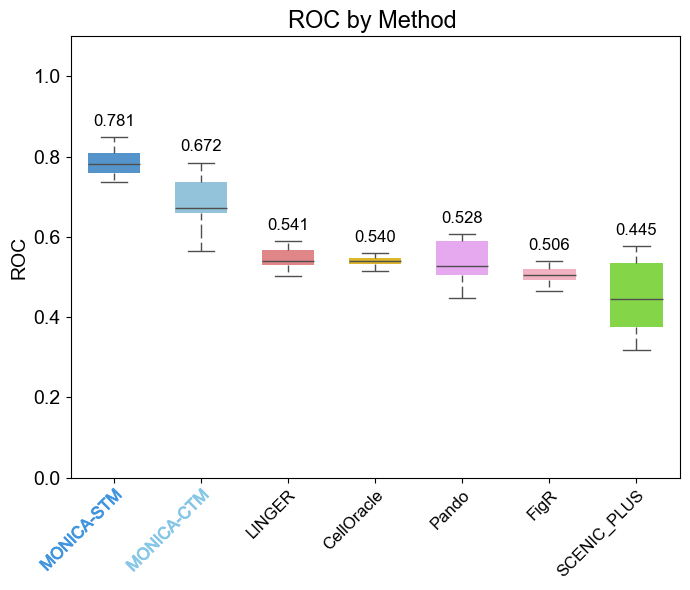

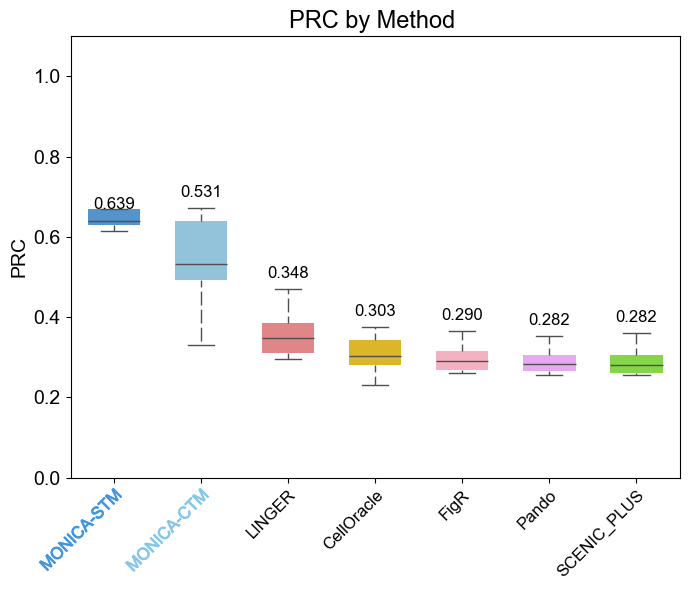

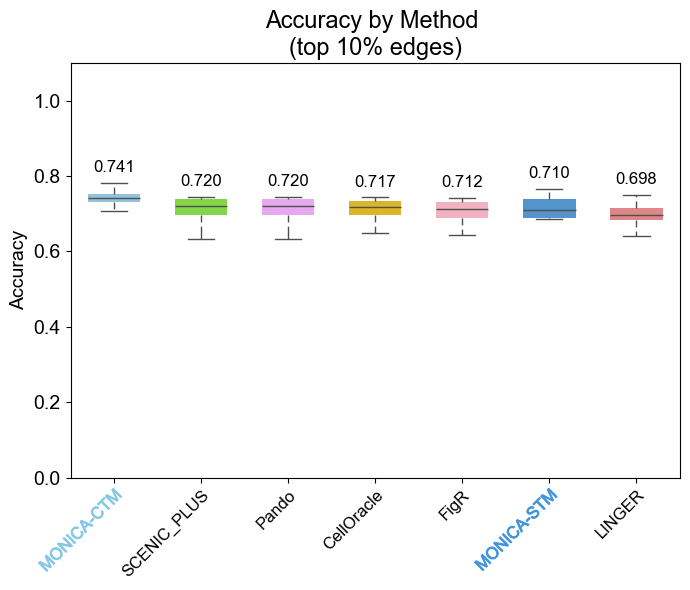

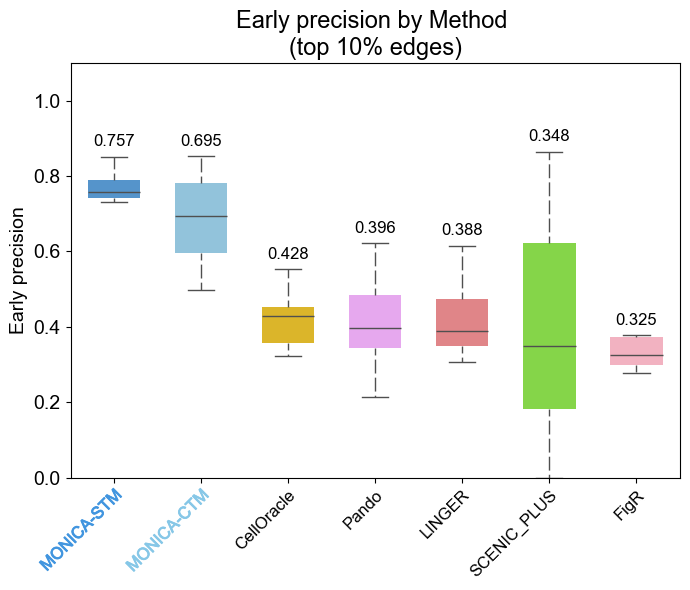

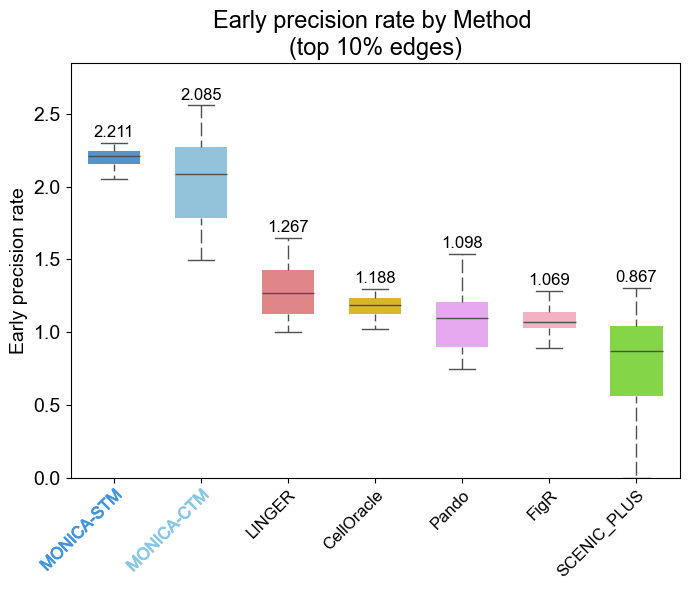

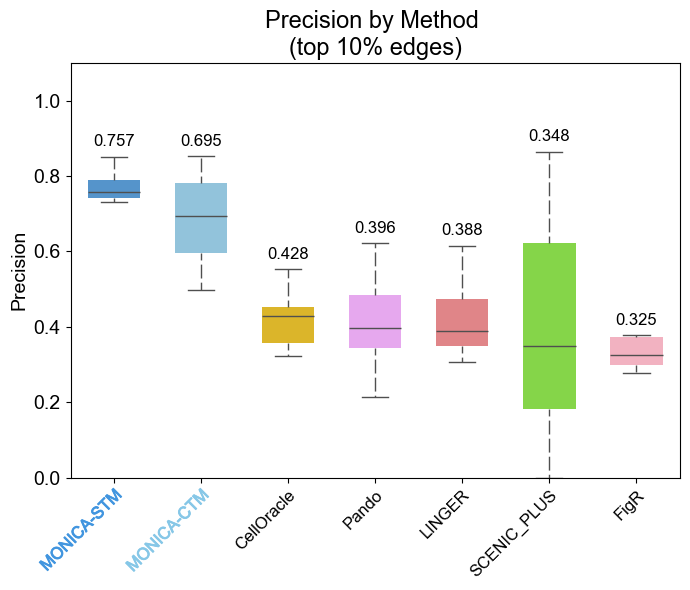

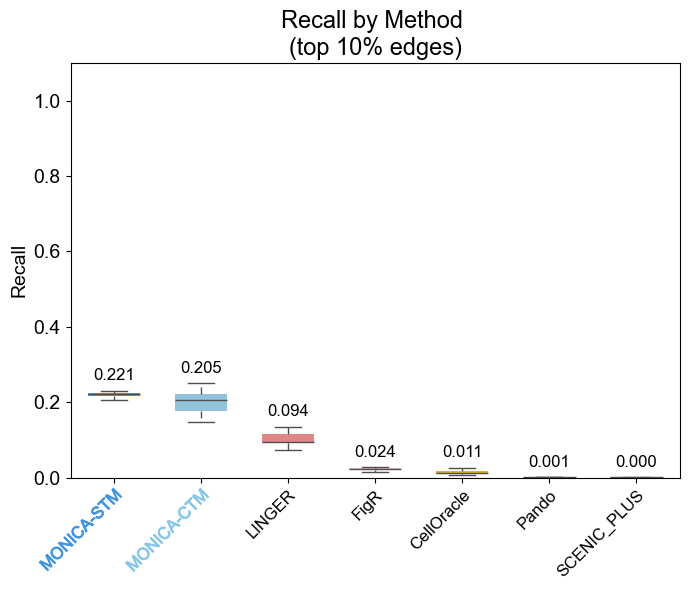

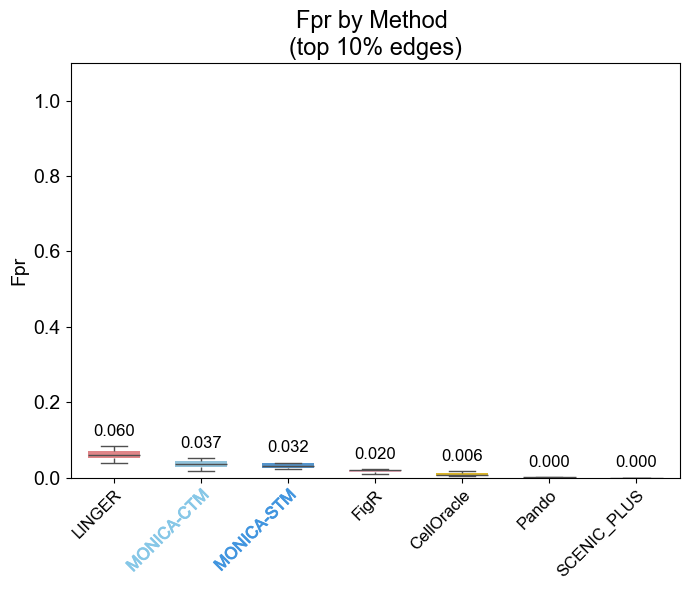

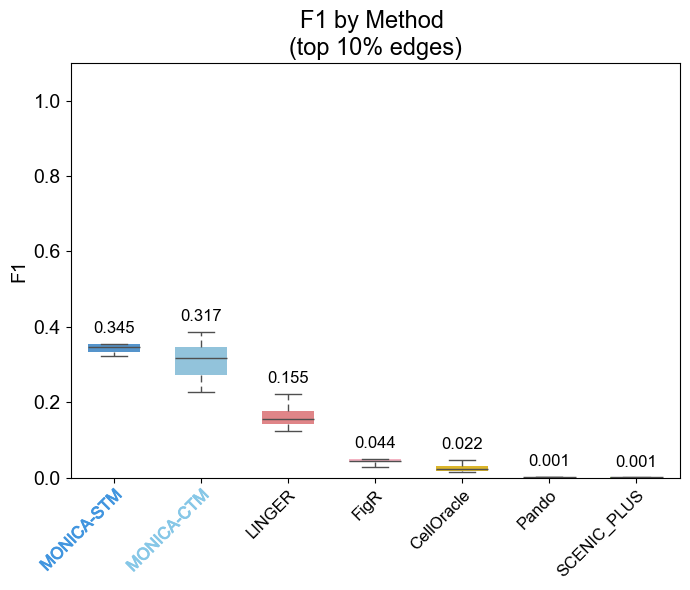

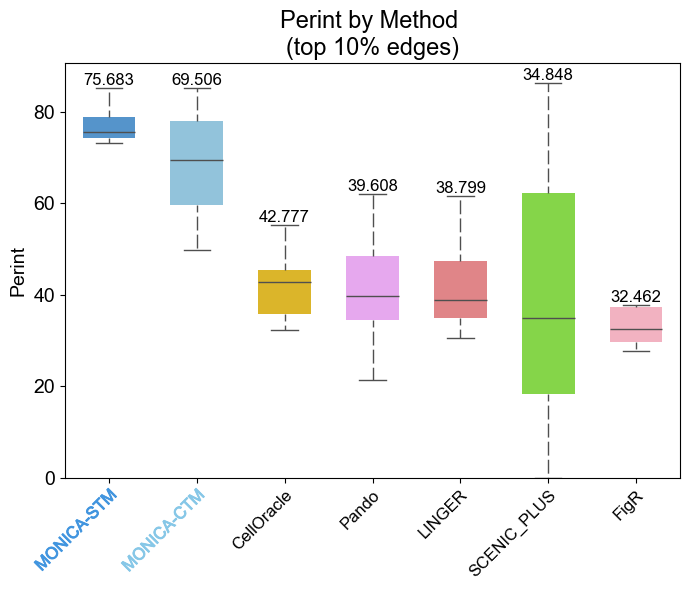

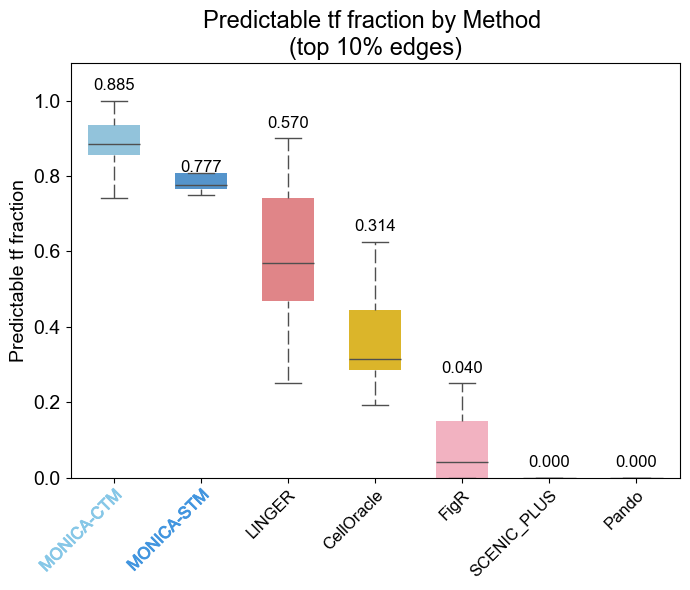

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = PROJECT_DIR / "fonts" / "Arial.ttf"

fm.fontManager.addfont(font_path)
arial_font = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [arial_font, "Helvetica", "Liberation Sans", "DejaVu Sans"]

logging.info(f"Using font: {arial_font}")

TFTG_MODEL_METHODS = {SELF_MODEL_METHOD, CROSS_MODEL_METHOD}


def _style_xticklabels(ax, originals, method_color_dict,
                       sample_rename_map=None, color_xticks=True,
                       rotation=45, fontsize=15):
    sample_rename_map = sample_rename_map or {}
    labels = [sample_rename_map.get(o, o) for o in originals]

    ax.set_xticks(range(len(originals)))
    ax.set_xticklabels(labels, rotation=rotation, ha="right",
                       fontsize=fontsize, rotation_mode="anchor")

    for tick, original in zip(ax.get_xticklabels(), originals):
        if original in TFTG_MODEL_METHODS:
            tick.set_fontsize(fontsize)
            if color_xticks:
                tick.set_color(method_color_dict.get(original, "black"))
            tick.set_path_effects([pe.withStroke(linewidth=0.6, foreground=tick.get_color())])
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")


def plot_method_box_and_whisker(
    full_metric_df, 
    selected_column, 
    method_color_dict, 
    sample_rename_map, 
    show_values_above_boxes=True,
    title_suffix_str="",
    ):
    
    metric_ordered_by_auroc = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    sanitized_name = selected_column.replace("_", " ").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
        sanitized_name = sanitized_name.replace("AU", "")
    else:
        sanitized_name = sanitized_name.capitalize()

    loosely_dashed = (5, (10, 3))
    
    fig = plt.figure(figsize=(7, 6))

    ax = sns.boxplot(
        data=full_metric_df, 
        x="method_name", 
        y=selected_column, 
        hue="method_name", 
        width=0.6,
        order=metric_ordered_by_auroc, 
        palette=method_color_dict,
        whiskerprops={"linestyle": loosely_dashed, "linewidth": 1},
        boxprops={"linewidth": 0},
        capprops={"linewidth": 1},
        medianprops={"linewidth": 1},
        showfliers=False
    )
    
    medians = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .reindex(metric_ordered_by_auroc)
    )

    for i, method in enumerate(metric_ordered_by_auroc):
        vals = full_metric_df.loc[full_metric_df["method_name"] == method, selected_column].dropna()
        if vals.empty:
            continue
        q1, q3 = vals.quantile([0.25, 0.75])
        top = vals[vals <= q3 + 1.5 * (q3 - q1)].max()

        if show_values_above_boxes:
            annotation = f"{vals.median():.3f}"
        else:
            ranks = medians.rank(method="min", ascending=False).astype(int)
            annotation = str(ranks[method])

        ax.text(i, top + 0.02, annotation, ha="center", va="bottom", fontsize=12)

    _style_xticklabels(
        ax,
        metric_ordered_by_auroc,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
        color_xticks=True,
        rotation=45,
        fontsize=12
    )

    plt.title(f"{sanitized_name} by Method {title_suffix_str}", fontsize=17)
    plt.xlabel("")
    plt.ylabel(sanitized_name, fontsize=14)
    plt.yticks(fontsize=14)
    
    if full_metric_df[selected_column].max() > 1:
        plt.ylim((0, full_metric_df[selected_column].max() * 1.05))
    else:
        plt.ylim((0, 1.10))
    
    plt.tight_layout()
    
    return fig, ax


method_display_name_map = {
    SELF_MODEL_METHOD: "MONICA-STM",
    CROSS_MODEL_METHOD: "MONICA-CTM",
}

method_color_dict = {
    SELF_MODEL_METHOD: "#4195df",
    CROSS_MODEL_METHOD: "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC_PLUS": "#82EC32",
    "FigR": "#FDA7BB",
    "GRaNIE": "#F98637",
}

metric_name_map = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "early_precision": "Early Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
}

# One row per (sample, cell type, method).
full_metric_df = celltype_metrics_df

# Rename the TF-TG model methods on the x-axis.
sample_rename_map = method_display_name_map

# Use the same top-edge settings that compute_metrics used.
top_fraction = float(full_metric_df["top_fraction"].iloc[0])
# top_k_edges = int(full_metric_df["max_edges"].iloc[0])
top_k_mode = "fraction"

method_comparison_boxplot_dir = (
    model_checkpoint.parent.parent / "celltype_method_comparison_plots" / "boxplots"
)
method_comparison_boxplot_dir.mkdir(parents=True, exist_ok=True)

# Selected columns by method box and whisker plot
methods = [
    "auroc", 
    "auprc", 
    "accuracy", 
    "early_precision", 
    "early_precision_rate",
    "precision", 
    "recall", 
    "fpr",
    "f1", 
    "perint", 
    "predictable_tf_fraction"
    ]

method_box_and_whisker_plots = {}
for selected_column in methods:
    
    sanitized_name = selected_column.replace("_", " ").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
        sanitized_name = sanitized_name.replace("AU", "")
    else:
        sanitized_name = sanitized_name.capitalize()
    
    if selected_column in ["early_precision", "early_precision_rate", "precision", "recall", "fpr", "f1", "accuracy", "perint", "predictable_tf_fraction"]:
        if top_k_mode == "fraction":
            title_suffix_str = f"\n(top {int(top_fraction * 100)}% edges)"
        else:
            title_suffix_str = ""
    else:
        title_suffix_str = ""

    method_comparison_boxplot_fig, method_comparison_boxplot_ax = plot_method_box_and_whisker(
        full_metric_df, 
        selected_column, 
        method_color_dict, 
        sample_rename_map, 
        show_values_above_boxes=True,
        title_suffix_str=title_suffix_str
    )
    
    method_box_and_whisker_plots[selected_column] = (method_comparison_boxplot_fig, method_comparison_boxplot_ax)

    plt.savefig(
        method_comparison_boxplot_dir / f"{sanitized_name.lower()}_by_method_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [35]:
method_comparison_boxplot_dir

PosixPath('/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3884266_20260921_100631_205004/celltype_method_comparison_plots/boxplots')

In [ ]:
def check_path_type(path: Path):
    print(path.name)

    def show_children(directory: Path, prefix: str):
        children = list(directory.iterdir())
        for i, child in enumerate(children):
            is_last = i == len(children) - 1
            print(f"{prefix}{'└──' if is_last else '├──'}{child.name}")

            if child.is_dir():
                show_children(child, prefix + ("    " if is_last else "│   "))

    if path.is_dir():
        show_children(path, "    ")

cache_dir = Path(test_run_config["cache_dir"])
print(f"Contents of {cache_dir.name}:")
check_path_type(cache_dir)

Contents of 759d90df23232599:
759d90df23232599
    ├──prepared_sources
    │   ├──mouse_liver__liver_sample
    │   │   ├──prepared
    │   │   │   ├──binding_scores_test_884a1c3d7ff0267b.pt
    │   │   │   ├──liver_sample
    │   │   │   │   └──atac_peak_tensor.pt
    │   │   │   └──binding_scores_val_4bfaabd17524b0ad.pt
    │   │   ├──edges_test.parquet
    │   │   ├──edges_train.parquet
    │   │   ├──prepared_manifest.json
    │   │   ├──edges_val.parquet
    │   │   └──cell_pools.npz
    │   └──mESC__E7.5_rep1
    │       ├──prepared
    │       │   ├──E7.5_rep1
    │       │   │   └──atac_peak_tensor.pt
    │       │   ├──binding_scores_test_9501f1d9583b7fa8.pt
    │       │   ├──binding_scores_train_98a195bb9b4b51c4.pt
    │       │   └──binding_scores_val_dfc21bbba1dd3652.pt
    │       ├──edges_test.parquet
    │       ├──edges_train.parquet
    │       ├──prepared_manifest.json
    │       ├──edges_val.parquet
    │       └──cell_pools.npz
    ├──input_scaler_manifest.json
  

### Generate Plots

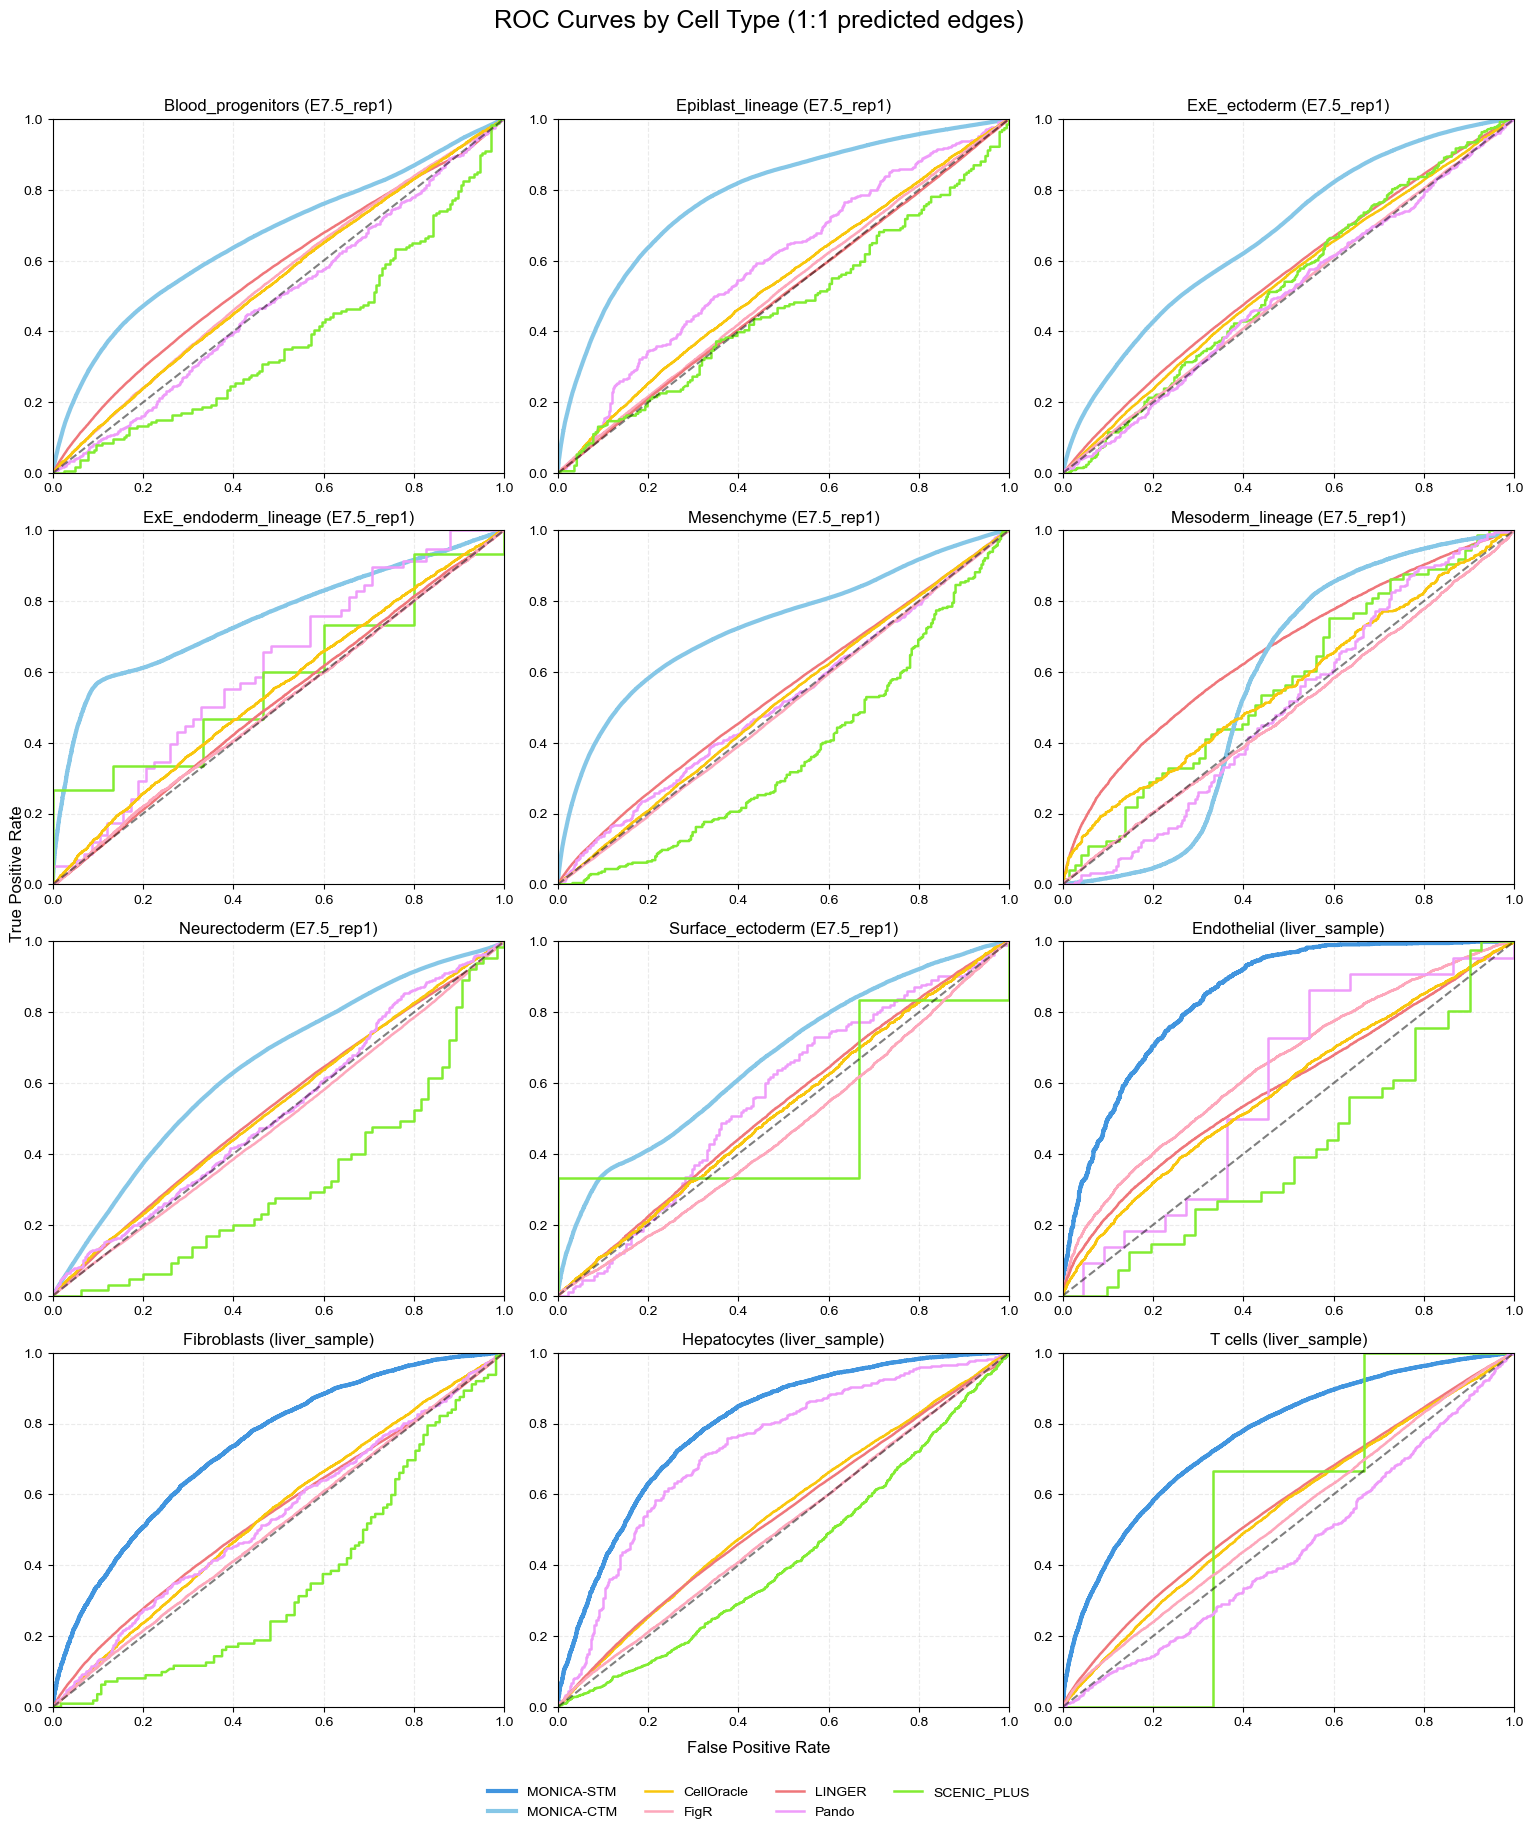

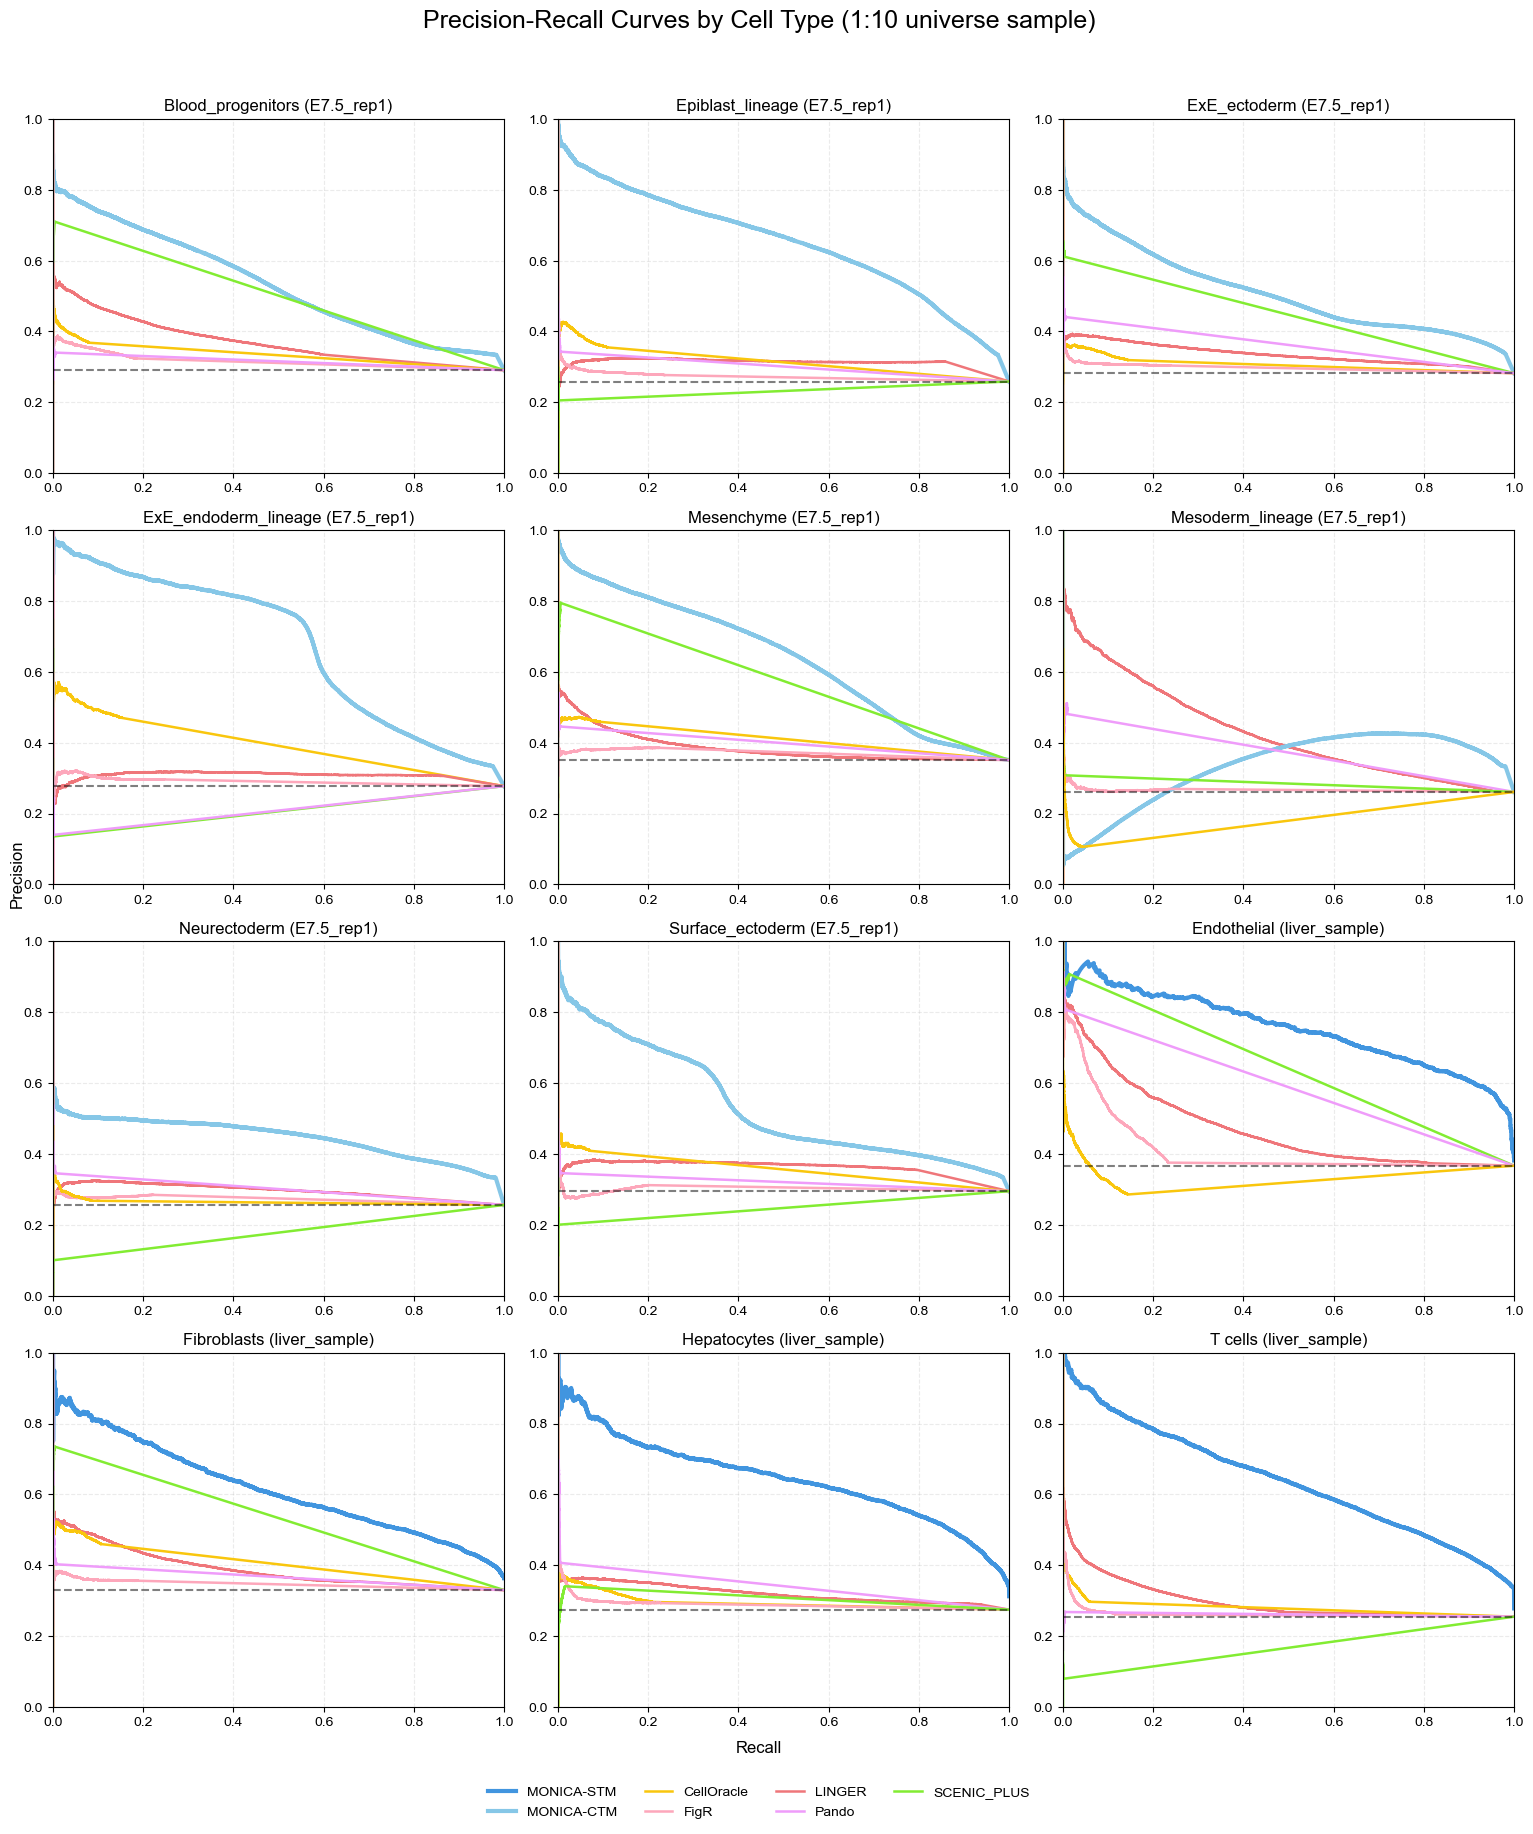

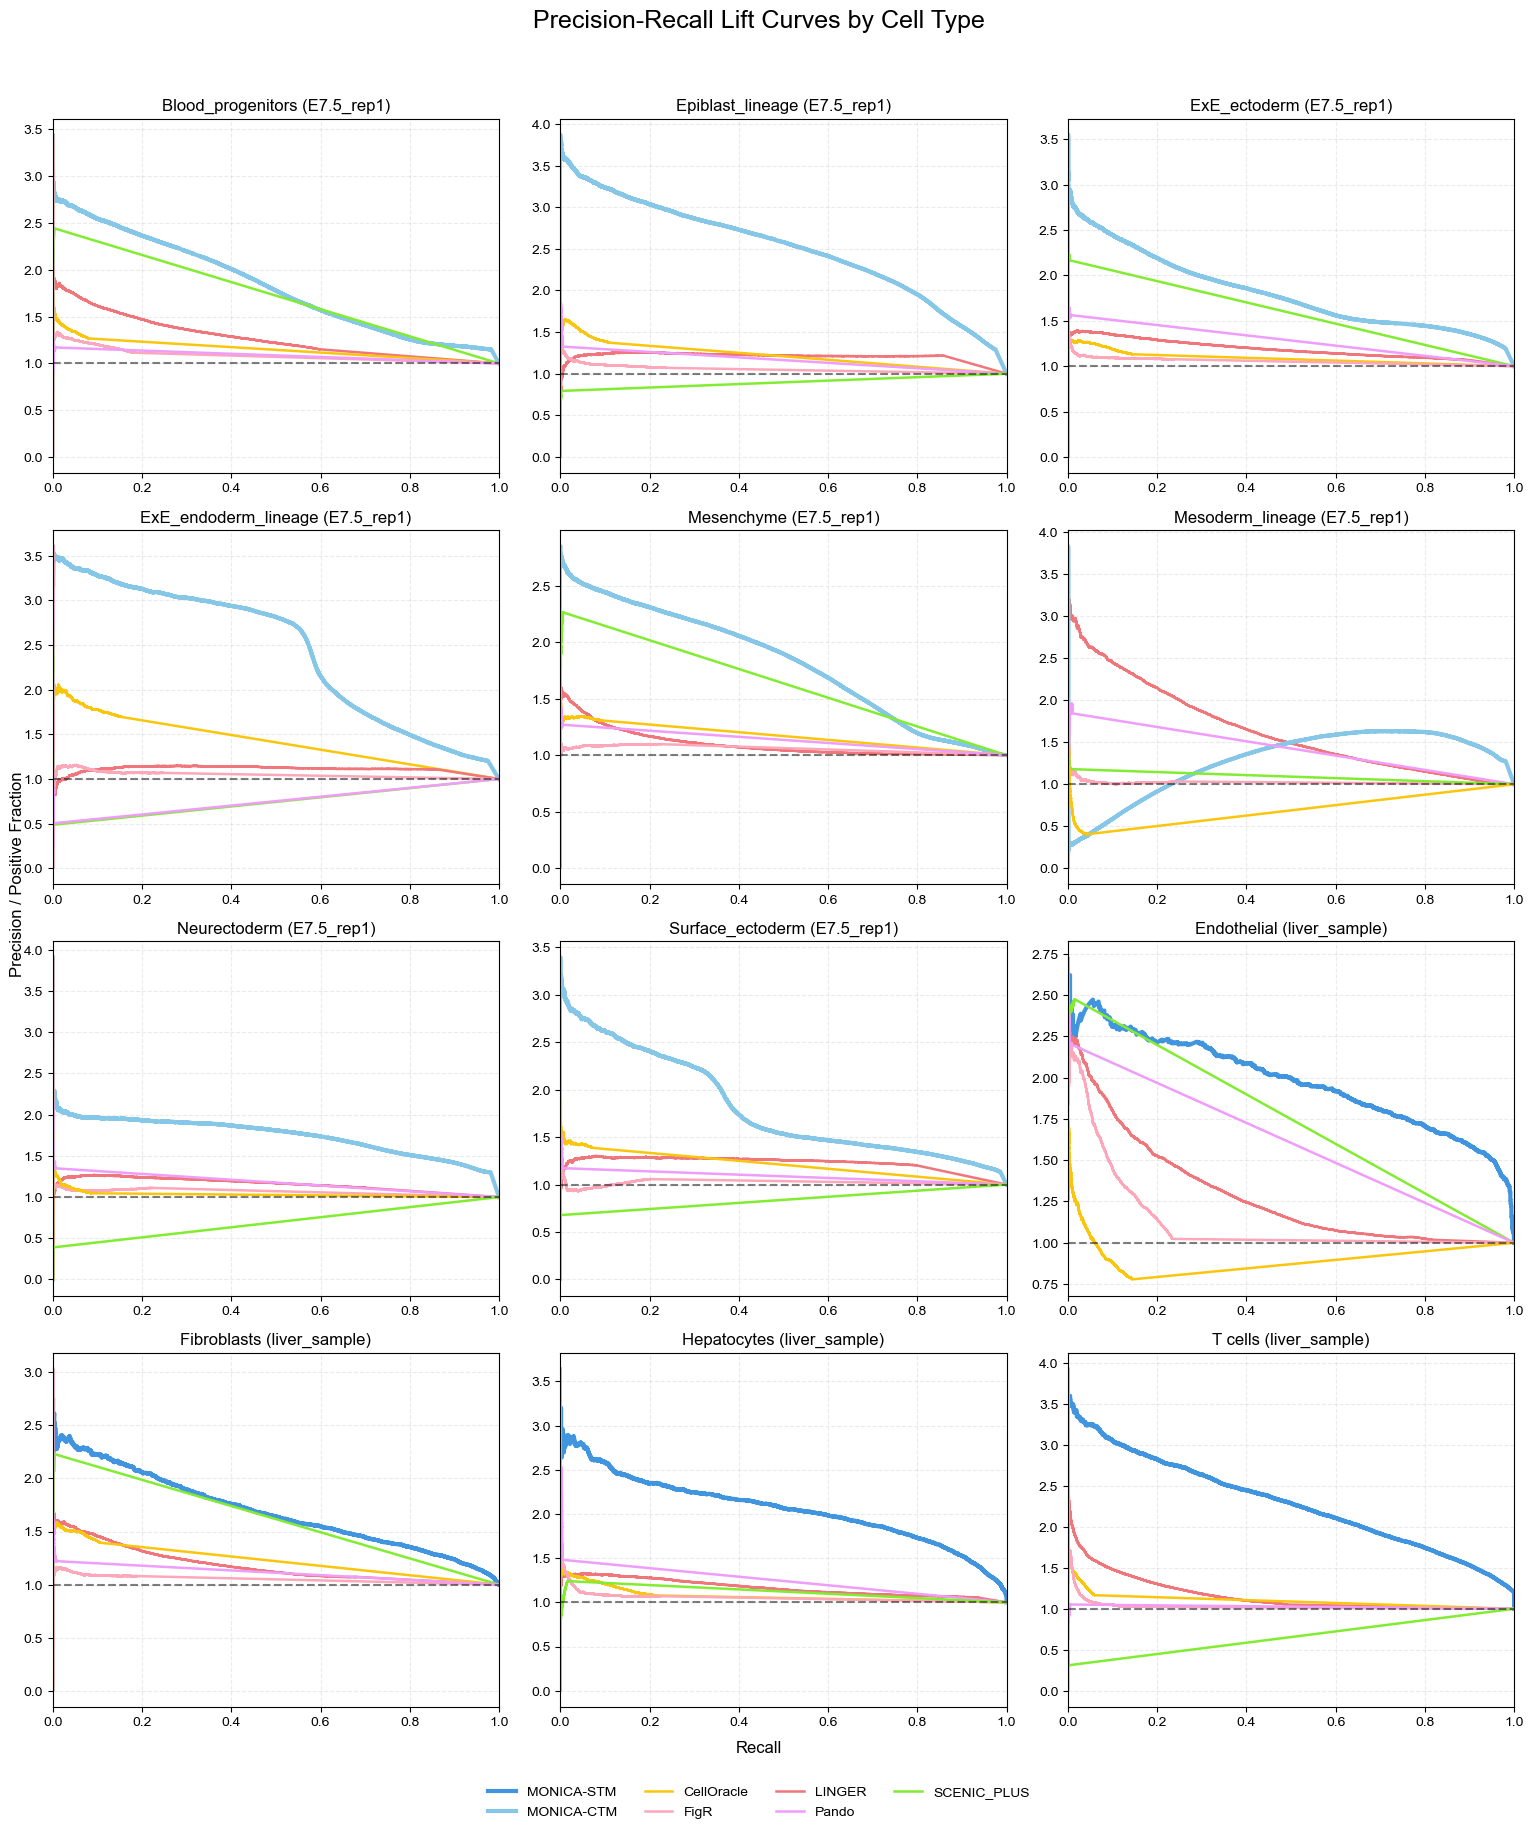

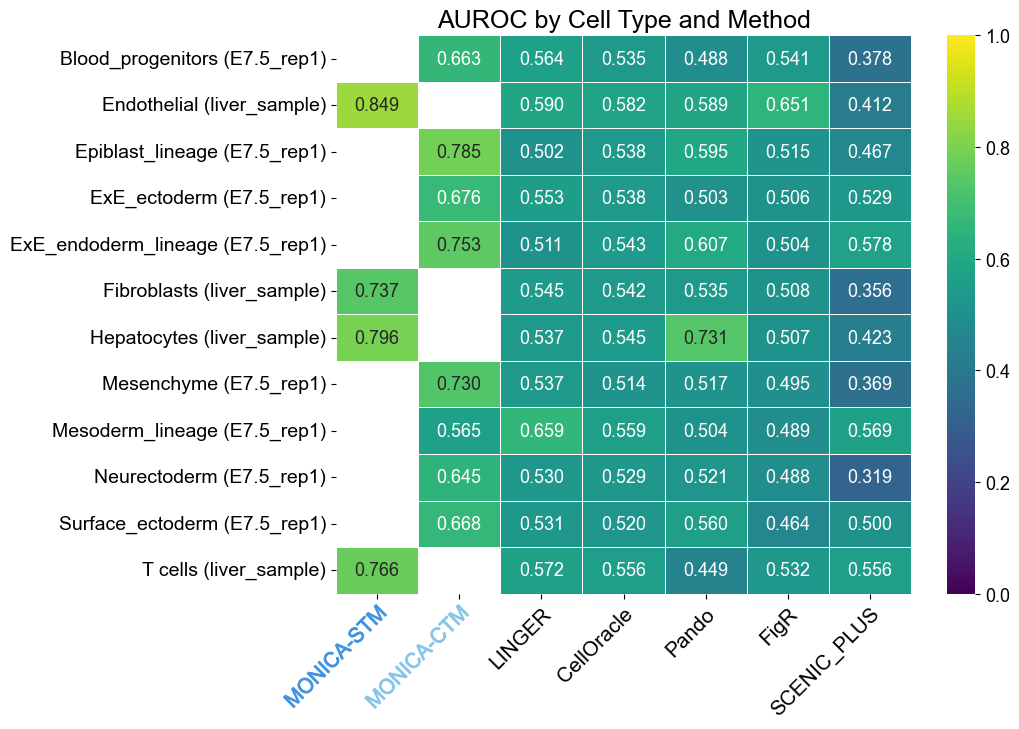

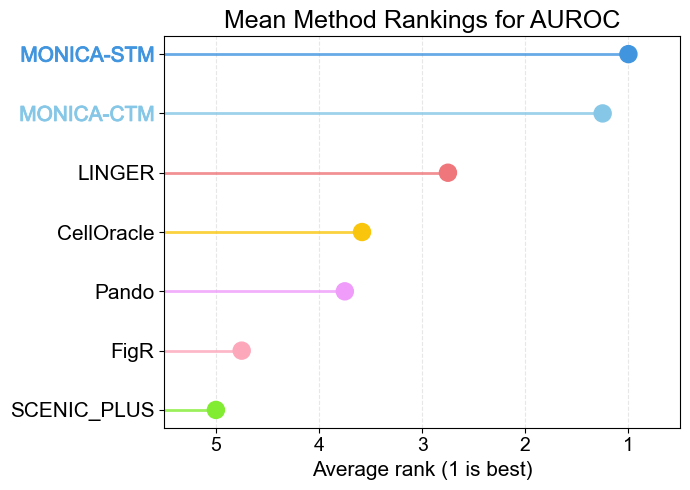

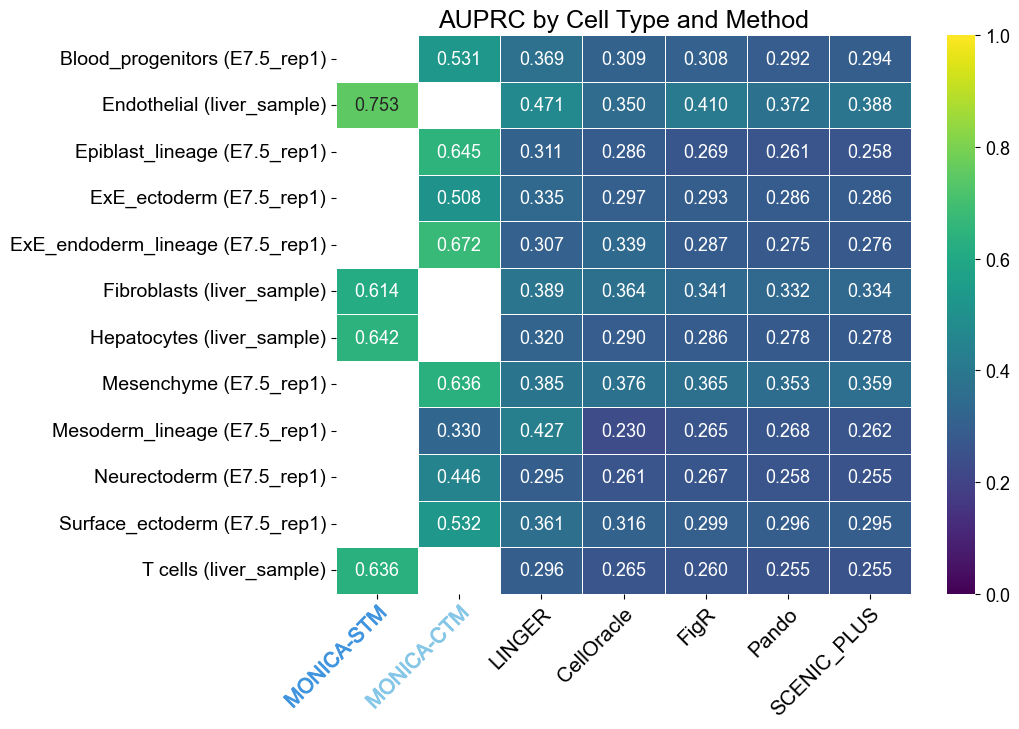

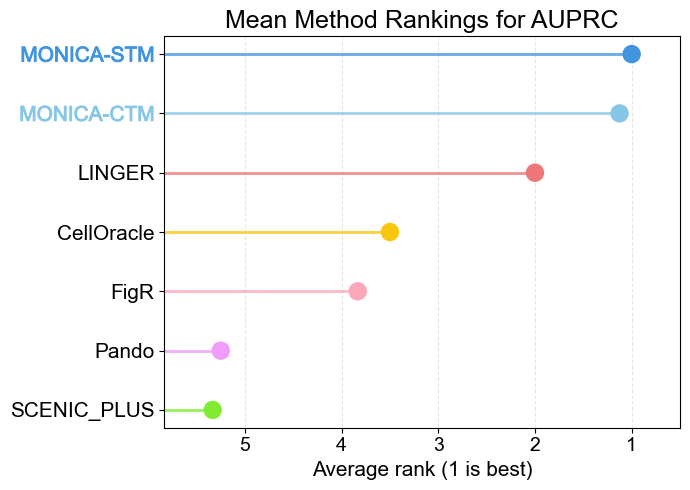

,method_name,sample_name,cell_type,auroc,rand_auroc,auprc,rand_auprc,early_precision,early_precision_rate,accuracy,...,top_fn,top_tn,n_universe_pairs,n_pos,n_neg,n_ground_truth_edges,ptf_alpha,ptf_multiple_testing,universe,panel
0,TF-TG Model (cross-trained),E7.5_rep1,Blood_progenitors,0.662995,0.501620,0.530843,0.291436,0.686252,2.058755,0.741224,...,120742,355334,520736,148868,297736,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes,Blood_progenitors (E7.5_rep1)
1,LINGER,E7.5_rep1,Blood_progenitors,0.564176,0.498708,0.368758,0.291582,0.472900,1.408205,0.706156,...,137212,353543,520736,100680,199126,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes,Blood_progenitors (E7.5_rep1)
2,FigR,E7.5_rep1,Blood_progenitors,0.540650,0.497985,0.308035,0.290063,0.375331,1.160482,0.705115,...,148128,363917,520736,28109,58801,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes,Blood_progenitors (E7.5_rep1)
3,CellOracle,E7.5_rep1,Blood_progenitors,0.535204,0.503495,0.308628,0.290068,0.431013,1.171626,0.708409,...,149978,367482,520736,12052,20709,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes,Blood_progenitors (E7.5_rep1)
4,Pando,E7.5_rep1,Blood_progenitors,0.487789,0.502347,0.291938,0.289624,0.304527,0.896252,0.709094,...,151316,369177,520736,826,1605,151390,0.05,Benjamini-Hochberg FDR,all_chromosomes,Blood_progenitors (E7.5_rep1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,LINGER,liver_sample,T cells,0.571944,0.500117,0.295986,0.254604,0.394621,1.476858,0.735472,...,205011,622697,868608,109285,299711,221151,0.05,Benjamini-Hochberg FDR,all_chromosomes,T cells (liver_sample)
68,CellOracle,liver_sample,T cells,0.556363,0.501658,0.264509,0.255394,0.385217,1.299544,0.744213,...,219426,644704,868608,13273,31504,221151,0.05,Benjamini-Hochberg FDR,all_chromosomes,T cells (liver_sample)
69,SCENIC_PLUS,liver_sample,T cells,0.555556,1.000000,0.254532,0.255466,0.000000,0.000000,0.745391,...,221151,647453,868608,3,36,221151,0.05,Benjamini-Hochberg FDR,all_chromosomes,T cells (liver_sample)
70,FigR,liver_sample,T cells,0.531884,0.499887,0.260136,0.255401,0.334284,1.282110,0.741649,...,217868,640919,868608,25607,72606,221151,0.05,Benjamini-Hochberg FDR,all_chromosomes,T cells (liver_sample)


Saved comparison plots and metrics to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3884265_20260921_100434_418733/celltype_method_comparison_plots


In [14]:
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve

metric_name_map = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "early_precision": "Early Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
}

comparison_plot_dir = (
    model_checkpoint.parent.parent / "celltype_method_comparison_plots"
)
comparison_plot_dir.mkdir(parents=True, exist_ok=True)

comparison_metric_df = celltype_metrics_df.copy()
comparison_metric_df["panel"] = (
    comparison_metric_df["cell_type"] + " (" + comparison_metric_df["sample_name"] + ")"
)

# Set method order: TF-TG models first, then the other methods.
available_methods = sorted(comparison_metric_df["method_name"].unique())
model_methods = [m for m in (SELF_MODEL_METHOD, CROSS_MODEL_METHOD) if m in available_methods]
method_order = model_methods + [m for m in available_methods if m not in model_methods]
fallback_colors = sns.color_palette("tab10", n_colors=max(len(method_order), 1))
for index, method in enumerate(method_order):
    method_color_dict.setdefault(method, fallback_colors[index])

all_comparison_figures = {}


def _display_method_name(method_name):
    return method_display_name_map.get(method_name, method_name)


def plot_cell_type_curve_panels(curve_kind, ncols=3):
    """
    One panel per (sample, cell type). Curves use the same samples as the
    metrics: ROC on the 1:1 predicted-edge sample, PR on the universe sample
    (unpredicted pairs scored 0, 10x negatives).
    """
    panels = list(
        comparison_metric_df[["sample_name", "cell_type", "panel"]]
        .drop_duplicates()
        .sort_values(["sample_name", "cell_type"])
        .itertuples(index=False)
    )
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5.2 * ncols, 4.5 * nrows), squeeze=False,
    )

    metric_column = "auroc" if curve_kind == "roc" else "auprc"
    for ax, (sample_name, cell_type, panel) in zip(axes.flat, panels):
        cell_metrics = comparison_metric_df[comparison_metric_df["panel"] == panel]
        plotted_methods = (
            cell_metrics.sort_values(metric_column, ascending=False)["method_name"].tolist()
        )
        positive_fraction = None
        for method_name in plotted_methods:
            curves = curve_data.get((sample_name, cell_type, method_name))
            if curves is None:
                continue

            if curve_kind == "roc":
                labels, scores = curves["roc_labels"], curves["roc_scores"]
            else:
                labels, scores = curves["pr_labels"], curves["pr_scores"]
            if len(np.unique(labels)) < 2:
                continue

            if curve_kind == "roc":
                x_values, y_values, _ = roc_curve(labels, scores)
            else:
                precision, recall, _ = precision_recall_curve(labels, scores)
                positive_fraction = float(labels.mean())
                x_values = recall
                y_values = precision / positive_fraction if curve_kind == "prc_lift" else precision

            ax.plot(
                x_values, y_values,
                color=method_color_dict[method_name],
                linewidth=3 if method_name in model_methods else 1.8,
            )

        if curve_kind == "roc":
            ax.plot([0, 1], [0, 1], color="black", linestyle="--", alpha=0.5)
            ax.set_ylim(0, 1)
        elif curve_kind == "prc":
            # Every method in a panel shares one universe sample, so one baseline.
            if positive_fraction is not None:
                ax.axhline(positive_fraction, color="black", linestyle="--", alpha=0.5)
            ax.set_ylim(0, 1)
        else:
            ax.axhline(1, color="black", linestyle="--", alpha=0.5)
        ax.set_xlim(0, 1)

        ax.set_title(panel)
        ax.grid(linestyle="--", alpha=0.25)

    for ax in axes.flat[len(panels):]:
        ax.set_visible(False)

    title_by_kind = {
        "roc": "ROC Curves by Cell Type (1:1 predicted edges)",
        "prc": "Precision-Recall Curves by Cell Type (1:10 universe sample)",
        "prc_lift": "Precision-Recall Lift Curves by Cell Type",
    }
    y_label_by_kind = {
        "roc": "True Positive Rate",
        "prc": "Precision",
        "prc_lift": "Precision / Positive Fraction",
    }
    fig.suptitle(title_by_kind[curve_kind], fontsize=18)
    fig.supxlabel("False Positive Rate" if curve_kind == "roc" else "Recall")
    fig.supylabel(y_label_by_kind[curve_kind])

    legend_handles = [
        Line2D(
            [0], [0], color=method_color_dict[method],
            linewidth=3 if method in model_methods else 1.8,
            label=_display_method_name(method),
        )
        for method in method_order
    ]
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    # Legend below the axis label; savefig(bbox_inches="tight") keeps it in the image.
    fig.legend(
        handles=legend_handles, loc="upper center", ncol=min(4, len(legend_handles)),
        bbox_to_anchor=(0.5, 0.0), frameon=False,
    )
    return fig, axes


for curve_kind in ("roc", "prc", "prc_lift"):
    fig, axes = plot_cell_type_curve_panels(curve_kind)
    fig.savefig(
        comparison_plot_dir / f"{curve_kind}_curves_by_cell_type.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    all_comparison_figures[f"{curve_kind}_curves"] = (fig, axes)
    plt.show()


import matplotlib as mpl
import matplotlib.patheffects as pe

# Custom font (arial_font is registered in the boxplot cell above).
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [arial_font, "Helvetica", "Liberation Sans", "DejaVu Sans"]


def _style_method_ticklabels(ticklabels, methods, fontsize):
    """Color and embolden the MONICA labels, as in the boxplots."""
    for tick, method in zip(ticklabels, methods):
        tick.set_fontsize(fontsize)
        if method in model_methods:
            tick.set_color(method_color_dict.get(method, "black"))
            tick.set_path_effects([pe.withStroke(linewidth=0.6, foreground=tick.get_color())])
        else:
            tick.set_color("black")


rank_summary = {}
for metric_name in ("auroc", "auprc"):
    rank_df = comparison_metric_df[["panel", "method_name", metric_name]].dropna().copy()
    rank_df["rank"] = (
        rank_df.groupby("panel")[metric_name]
        .rank(method="min", ascending=False)
    )
    average_rank = (
        rank_df.groupby("method_name", as_index=False)["rank"]
        .mean().rename(columns={"rank": "average_rank"})
        .sort_values("average_rank")
    )
    ordered_methods = average_rank["method_name"].tolist()

    metric_matrix = rank_df.pivot(
        index="panel", columns="method_name", values=metric_name,
    ).reindex(columns=ordered_methods)
    fig_heatmap, ax_heatmap = plt.subplots(
        figsize=(1.25 * len(ordered_methods) + 2, 0.45 * len(metric_matrix) + 2),
    )
    sns.heatmap(
        metric_matrix, annot=True, fmt=".3f", cmap="viridis",
        vmin=0, vmax=1, linewidths=0.5, linecolor="white", ax=ax_heatmap,
        annot_kws={"fontsize": 13},
    )
    ax_heatmap.set_xticklabels(
        [_display_method_name(method) for method in ordered_methods],
        rotation=45, ha="right", rotation_mode="anchor",
    )
    _style_method_ticklabels(ax_heatmap.get_xticklabels(), ordered_methods, fontsize=15)
    ax_heatmap.tick_params(axis="y", labelsize=14)
    ax_heatmap.collections[0].colorbar.ax.tick_params(labelsize=13)
    ax_heatmap.set_xlabel("")
    ax_heatmap.set_ylabel("")
    ax_heatmap.set_title(f"{metric_name.upper()} by Cell Type and Method", fontsize=18)
    fig_heatmap.tight_layout()
    fig_heatmap.savefig(
        comparison_plot_dir / f"{metric_name}_method_heatmap.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    plt.show()

    fig_rank, ax_rank = plt.subplots(figsize=(7, 5))
    y_positions = np.arange(len(average_rank))
    max_rank = max(float(average_rank["average_rank"].max()) + 0.5, 1.5)
    colors = [method_color_dict[method] for method in ordered_methods]
    ax_rank.hlines(
        y_positions, max_rank, average_rank["average_rank"],
        color=colors, linewidth=2, alpha=0.8,
    )
    ax_rank.scatter(
        average_rank["average_rank"], y_positions,
        color=colors, s=150, zorder=3,
    )
    ax_rank.set_yticks(y_positions)
    ax_rank.set_yticklabels([_display_method_name(method) for method in ordered_methods])
    _style_method_ticklabels(ax_rank.get_yticklabels(), ordered_methods, fontsize=15)
    ax_rank.tick_params(axis="x", labelsize=14)
    ax_rank.set_xlim(max_rank, 0.5)
    ax_rank.invert_yaxis()
    ax_rank.set_xlabel("Average rank (1 is best)", fontsize=15)
    ax_rank.set_title(f"Mean Method Rankings for {metric_name.upper()}", fontsize=18)
    ax_rank.grid(axis="x", linestyle="--", alpha=0.3)
    fig_rank.tight_layout()
    fig_rank.savefig(
        comparison_plot_dir / f"average_{metric_name}_rank_lollipop.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    plt.show()

    rank_summary[metric_name] = {
        "rank_data": rank_df,
        "average_rank": average_rank,
        "heatmap": (fig_heatmap, ax_heatmap),
        "lollipop": (fig_rank, ax_rank),
    }

all_comparison_figures["rank_summary"] = rank_summary
comparison_metric_df.to_csv(
    comparison_plot_dir / "comparison_metrics_by_cell_type.csv", index=False,
)
display(
    comparison_metric_df.sort_values(
        ["sample_name", "cell_type", "auroc"], ascending=[True, True, False],
    ).reset_index(drop=True)
)
print(f"Saved comparison plots and metrics to {comparison_plot_dir}")
